STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 12 equal-width SFR bins for rMZR

Σ_SFR range:
  Min: -4.567
  Max: 0.019
  Range: 4.586

Bin width: 0.382

12 equal-width SFR bins:
  Bin 1: -4.57–-4.18
  Bin 2: -4.18–-3.80
  Bin 3: -3.80–-3.42
  Bin 4: -3.42–-3.04
  Bin 5: -3.04–-2.66
  Bin 6: -2.66–-2.27
  Bin 7: -2.27–-1.89
  Bin 8: -1.89–-1.51
  Bin 9: -1.51–-1.13
  Bin 10: -1.13–-0.75
  Bin 11: -0.75–-0.36
  Bin 12: -0.36–0.02

STEP 3: Defining 12 Σ_* bins with equal width for Z_gas-Σ_SFR

Σ_* Statistics:
  Min:

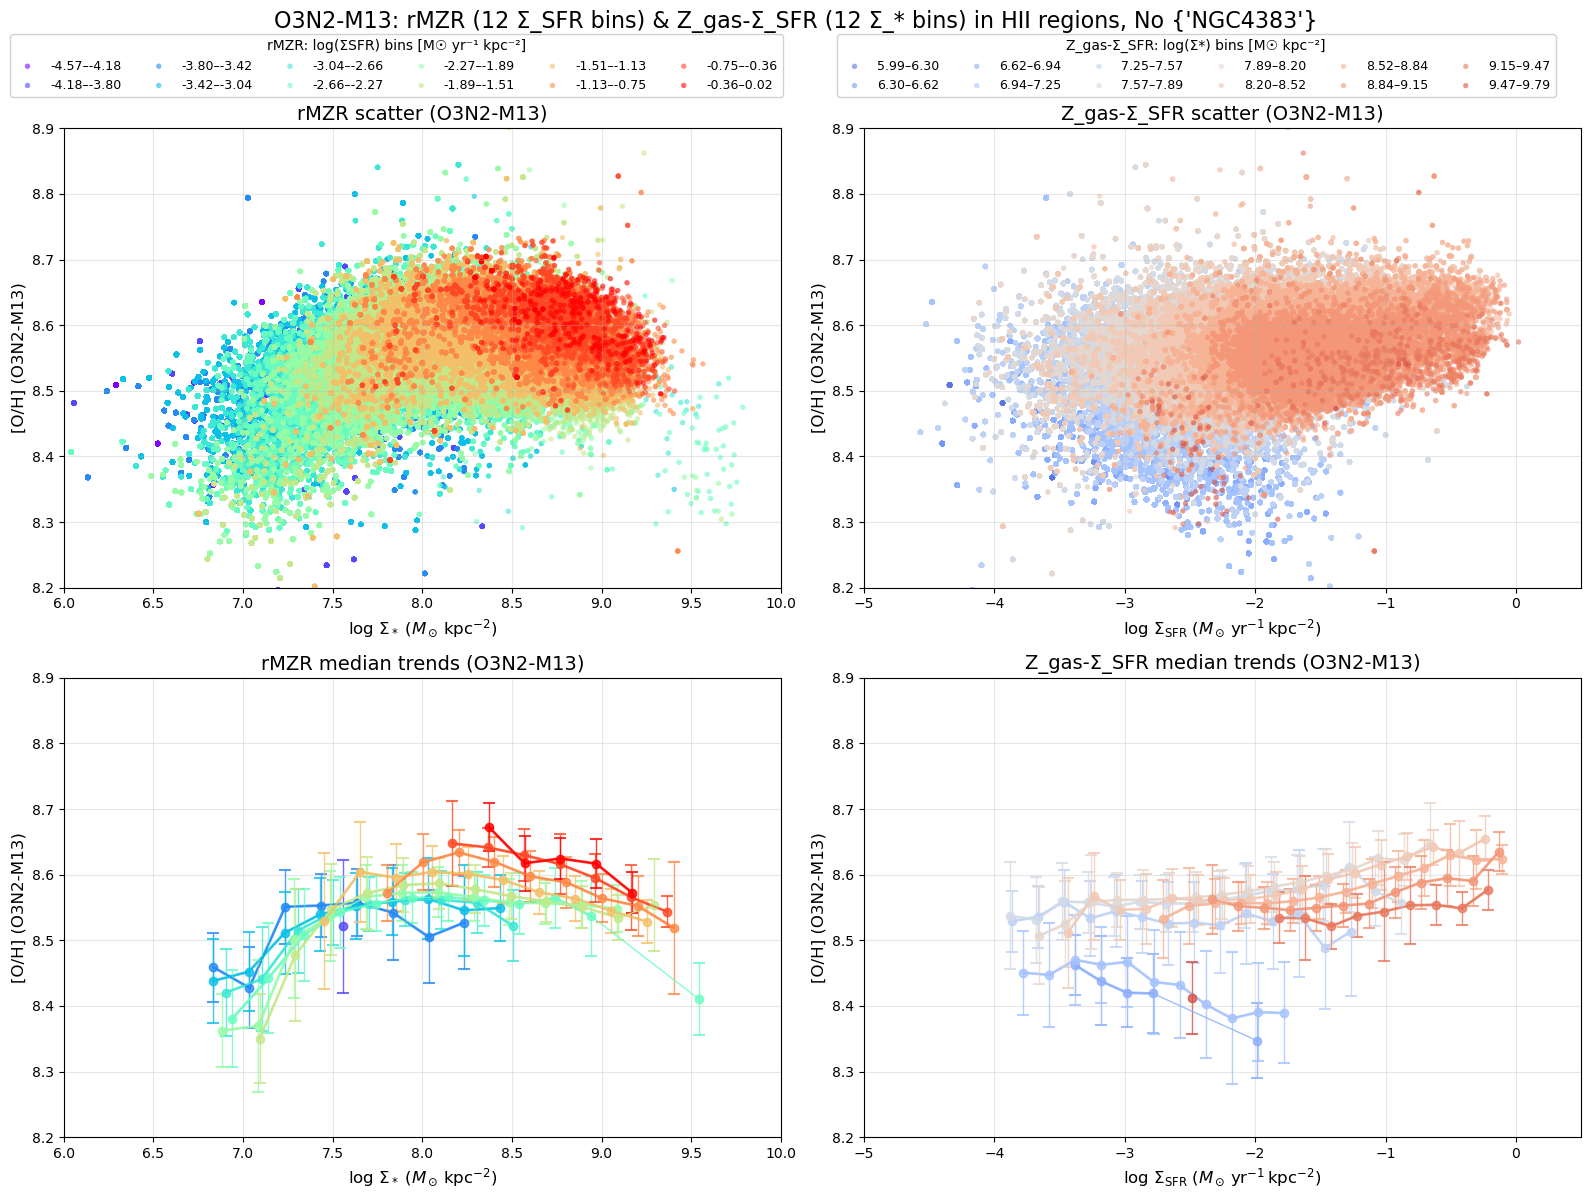


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (12 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (12 Σ_* bins)
  Bottom-left: rMZR median trends (12 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (12 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [1]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 12 equal-width Σ_SFR bins for rMZR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 12 equal-width SFR bins for rMZR")
print("="*80)

# Get SFR range
sfr_min = np.min(all_logSigmaSFR_HII)
sfr_max = np.max(all_logSigmaSFR_HII)
sfr_range = sfr_max - sfr_min

print(f"\nΣ_SFR range:")
print(f"  Min: {sfr_min:.3f}")
print(f"  Max: {sfr_max:.3f}")
print(f"  Range: {sfr_range:.3f}")

# Define 12 bins with equal width
n_bins = 12
bin_width = sfr_range / n_bins

print(f"\nBin width: {bin_width:.3f}")

# Create bin edges
sfr_bin_edges = np.linspace(sfr_min, sfr_max, n_bins + 1)

# Create bin labels
bin_labels = []
for i in range(n_bins):
    bin_labels.append(f'{sfr_bin_edges[i]:.2f}–{sfr_bin_edges[i+1]:.2f}')

print(f"\n12 equal-width SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 12 Σ_* bins for Z_gas-Σ_SFR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 12 Σ_* bins with equal width for Z_gas-Σ_SFR")
print("="*80)

# Calculate the actual data range
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics:")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 12 Σ_* bins with equal width across the actual data range
n_bins_sigmaM = 12
bin_width_sigmaM = sigmaM_range / n_bins_sigmaM
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

print(f"  Bin width: {bin_width_sigmaM:.3f} dex")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n12 Σ_* bins (equal width):")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 12 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 12 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (12 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    elif i == n_bins - 1:
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII <= sfr_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.set_title(f'rMZR scatter ({calib_name_HII})', fontsize=14)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.set_title(f'rMZR median trends ({calib_name_HII})', fontsize=14)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 12 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (12 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_scatter.set_title(f'Z_gas-Σ_SFR scatter ({calib_name_HII})', fontsize=14)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_median.set_title(f'Z_gas-Σ_SFR median trends ({calib_name_HII})', fontsize=14)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# Add overall title
fig.suptitle(f'{calib_name_HII}: rMZR (12 Σ_SFR bins) & Z_gas-Σ_SFR (12 Σ_* bins) in HII regions, No {excluded_galaxies}', 
             fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣSFR) bins [M☉ yr⁻¹ kpc⁻²]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_SFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('Combined_rMZR_Zgas_SigmaSFR_O3N2M13_2x2_12bins.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_rMZR_Zgas_SigmaSFR_O3N2M13_2x2_12bins.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (12 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (12 Σ_* bins)")
print("  Bottom-left: rMZR median trends (12 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (12 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881
NGC4330 pixels (HII): 42998

STEP 2: Defining 12 equal-width SFR bins for rMZR (NGC4330 range)

Σ_SFR range (NGC4330):
  Min: -4.567
  Max: -1.155
  Range: 3.411

Bin width: 0.284

12 equal-width SFR bins (NGC4330):
  Bin 1: -4.57–-4.28
  Bin 2: -4.28–-4.00
  Bin 3: -4.00–-3.71
  Bin 4: -3.71–-3.43
  Bin 5: -3.43–-3.15
  Bin 6: -3.15–-2.86
  Bin 7: -2.86–-2.58
  Bin 8: -2.58–-2.29
  Bin 9: -2.29–-2.01
  Bin 10: -2.01–-1.72
  Bin 11: -1.72–-1.44
  Bin 12: -1.44–-1.16

STEP 3: Defining 12

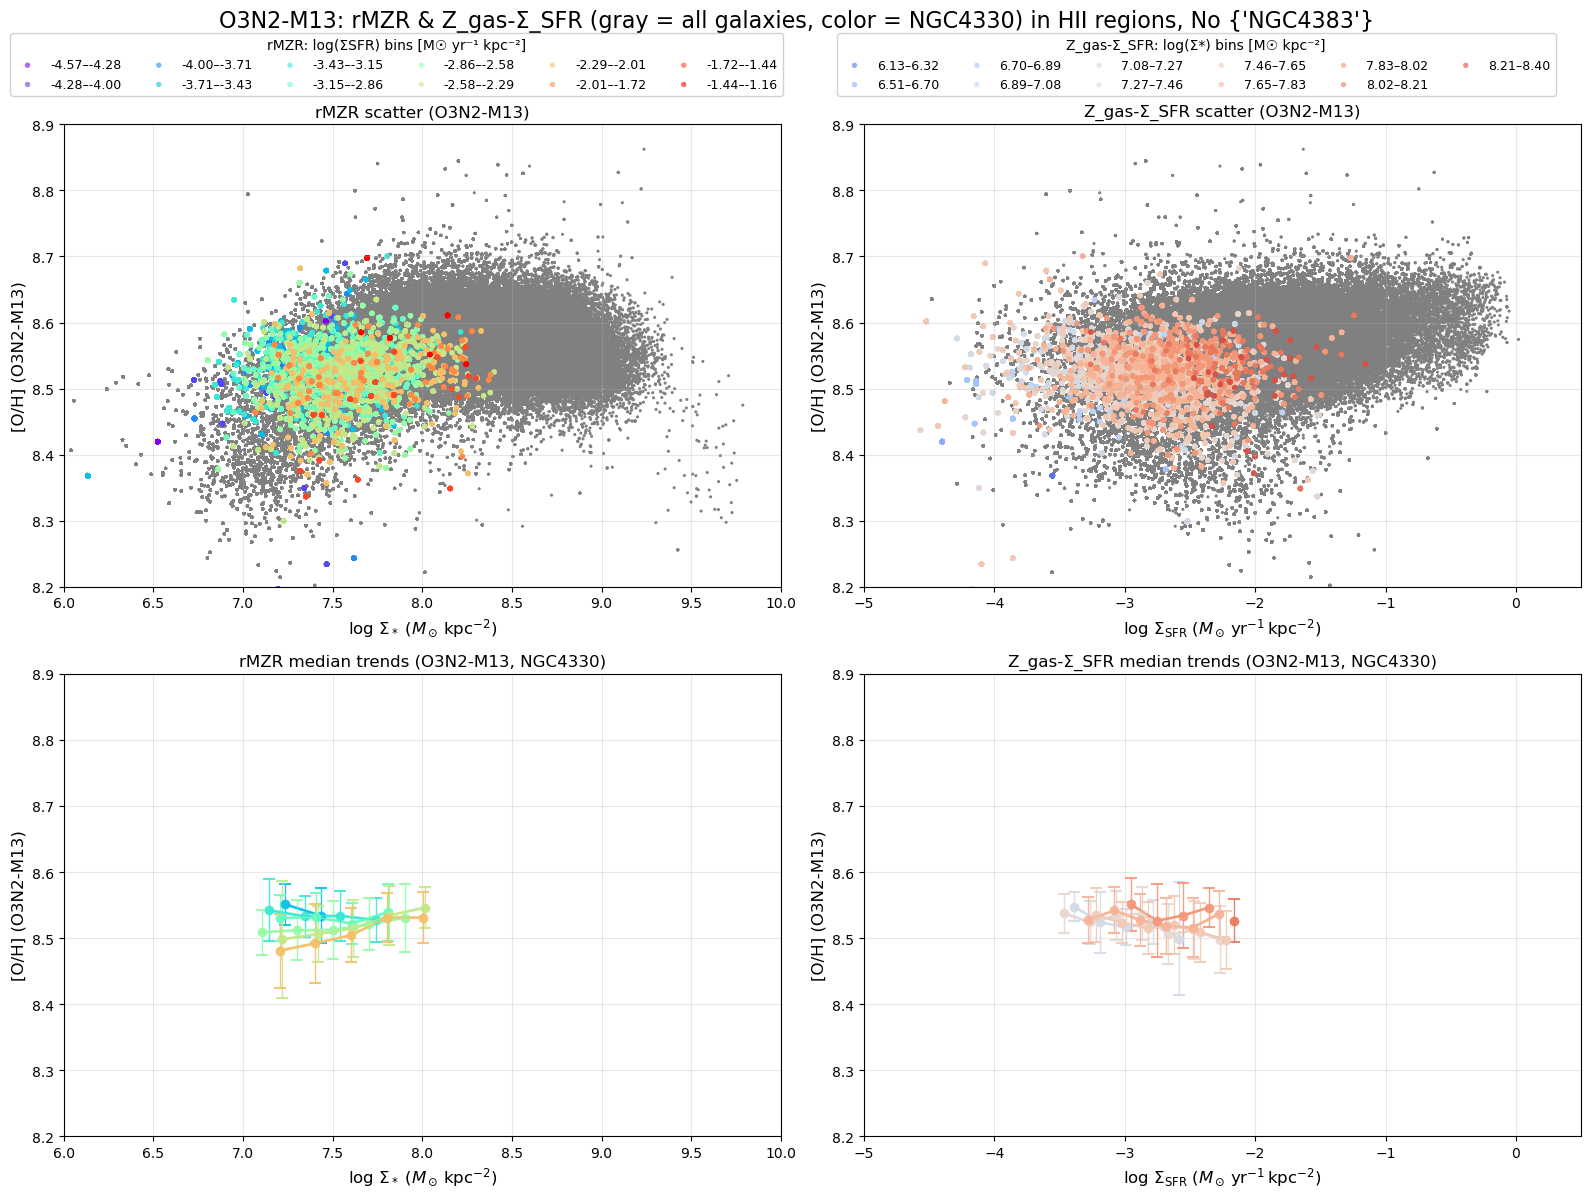


COMPLETED: NGC4330-highlighted rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure with all-galaxy background and NGC4330 highlight from 13 galaxies
Galaxies included (background): IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (gray = all, color = NGC4330 by Σ_SFR bin)
  Top-right: Z_gas-Σ_SFR scatter (gray = all, color = NGC4330 by Σ_* bin)
  Bottom-left: rMZR median trends (NGC4330)
  Bottom-right: Z_gas-Σ_SFR median trends (NGC4330)
  Shared y-range: 8.2 to 8.9


In [2]:
# ======================================================================================================
# Combined Analysis with NGC4330 highlight: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter (gray background = all galaxies, color = NGC4330)
#   Top-right: Z_gas-Σ_SFR scatter (gray background = all galaxies, color = NGC4330)
#   Bottom-left: rMZR median trends (NGC4330)
#   Bottom-right: Z_gas-Σ_SFR median trends (NGC4330)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    if np.isinf(x_min) or np.isinf(x_max):
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    if np.isnan(x_min) or np.isnan(x_max):
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if len(bin_edges) < 2:
        return (np.array([]), np.array([]), np.array([]), np.array([]), np.array([]))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies & isolate NGC4330
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

ngc4330_logSigmaM_HII = []
ngc4330_logSigmaSFR_HII = []
ngc4330_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data (combined background)
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())

        # Store NGC4330 data separately
        if gal == 'NGC4330':
            ngc4330_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
            ngc4330_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
            ngc4330_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

ngc4330_logSigmaM_HII = np.array(ngc4330_logSigmaM_HII)
ngc4330_logSigmaSFR_HII = np.array(ngc4330_logSigmaSFR_HII)
ngc4330_oh_o3n2_m13_HII = np.array(ngc4330_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")
print(f"NGC4330 pixels (HII): {len(ngc4330_logSigmaM_HII)}")

if len(ngc4330_logSigmaM_HII) == 0:
    raise ValueError("No valid NGC4330 pixels found. Cannot proceed with NGC4330-highlight plots.")

# ==============================================================================
# STEP 2: Define 12 equal-width Σ_SFR bins for rMZR analysis (based on NGC4330)
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 12 equal-width SFR bins for rMZR (NGC4330 range)")
print("="*80)

# Get SFR range (NGC4330)
sfr_min = np.min(ngc4330_logSigmaSFR_HII)
sfr_max = np.max(ngc4330_logSigmaSFR_HII)
sfr_range = sfr_max - sfr_min

print(f"\nΣ_SFR range (NGC4330):")
print(f"  Min: {sfr_min:.3f}")
print(f"  Max: {sfr_max:.3f}")
print(f"  Range: {sfr_range:.3f}")

# Define 12 bins with equal width (NGC4330)
n_bins = 12
bin_width = sfr_range / n_bins if n_bins > 0 else np.nan

print(f"\nBin width: {bin_width:.3f}")

# Create bin edges (NGC4330)
sfr_bin_edges = np.linspace(sfr_min, sfr_max, n_bins + 1)

# Create bin labels
bin_labels = []
for i in range(n_bins):
    bin_labels.append(f'{sfr_bin_edges[i]:.2f}–{sfr_bin_edges[i+1]:.2f}')

print(f"\n12 equal-width SFR bins (NGC4330):")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 12 Σ_* bins for Z_gas-Σ_SFR analysis (based on NGC4330)
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 12 Σ_* bins with equal width for Z_gas-Σ_SFR (NGC4330 range)")
print("="*80)

# Calculate the actual data range (NGC4330)
sigmaM_min = np.min(ngc4330_logSigmaM_HII)
sigmaM_max = np.max(ngc4330_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics (NGC4330):")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 12 Σ_* bins with equal width across the NGC4330 data range
n_bins_sigmaM = 12
bin_width_sigmaM = sigmaM_range / n_bins_sigmaM if n_bins_sigmaM > 0 else np.nan
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

print(f"  Bin width: {bin_width_sigmaM:.3f} dex")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n12 Σ_* bins (NGC4330):")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 12 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (background = all, highlight = NGC4330)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot highlighting NGC4330")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Assign axes (swap top-right with bottom-left for layout)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (gray background = all, color-coded = NGC4330)
# =============================================================================
print(f"\n--- Processing rMZR (12 Σ_SFR bins) ---")

# Background scatter for all galaxies
ax_rMZR_scatter.scatter(all_logSigmaM_HII, all_oh_o3n2_m13_HII, c='gray', s=5, alpha=1.0,
                        edgecolors='none', rasterized=True)

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # NGC4330 binning in Σ_SFR
    if i == 0:
        in_bin_ngc4330 = (ngc4330_logSigmaSFR_HII >= sfr_bin_edges[i]) & (ngc4330_logSigmaSFR_HII < sfr_bin_edges[i+1])
    elif i == n_bins - 1:
        in_bin_ngc4330 = (ngc4330_logSigmaSFR_HII >= sfr_bin_edges[i]) & (ngc4330_logSigmaSFR_HII <= sfr_bin_edges[i+1])
    else:
        in_bin_ngc4330 = (ngc4330_logSigmaSFR_HII >= sfr_bin_edges[i]) & (ngc4330_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_ngc4330 = np.sum(in_bin_ngc4330)
    
    if n_pixels_ngc4330 >= 10:
        # NGC4330 data for this bin (x=Σ_*, y=[O/H])
        x_bin_ngc4330 = ngc4330_logSigmaM_HII[in_bin_ngc4330]
        y_bin_ngc4330 = ngc4330_oh_o3n2_m13_HII[in_bin_ngc4330]
        
        # Scatter plot (NGC4330 highlight)
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_ngc4330, y_bin_ngc4330, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends (NGC4330 only)
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_ngc4330, y_bin_ngc4330, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                                    color=colors_sfr[i], marker='o', markersize=6, 
                                    linewidth=1, capsize=4, capthick=1.5, alpha=0.9)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                                        [medians_HII[j], medians_HII[j + 1]], 
                                        color=colors_sfr[i], linewidth=2, alpha=0.9)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] (O3N2-M13)', fontsize=12)
ax_rMZR_scatter.set_title('rMZR scatter (O3N2-M13)')
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends (NGC4330)
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] (O3N2-M13)', fontsize=12)
ax_rMZR_median.set_title('rMZR median trends (O3N2-M13, NGC4330)')
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins (NGC4330): {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (gray background = all, color-coded = NGC4330)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (12 Σ_* bins) ---")

# Background scatter for all galaxies
ax_Zgas_scatter.scatter(all_logSigmaSFR_HII, all_oh_o3n2_m13_HII, c='gray', s=5, alpha=1.0,
                        edgecolors='none', rasterized=True)

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # NGC4330 binning in Σ_*
    if i == 0:
        in_bin_ngc4330 = (ngc4330_logSigmaM_HII >= sigmaM_bin_edges[i]) & (ngc4330_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_ngc4330 = (ngc4330_logSigmaM_HII >= sigmaM_bin_edges[i]) & (ngc4330_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_ngc4330 = (ngc4330_logSigmaM_HII >= sigmaM_bin_edges[i]) & (ngc4330_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_ngc4330 = np.sum(in_bin_ngc4330)
    
    if n_pixels_ngc4330 >= 10:
        # NGC4330 data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_ngc4330 = ngc4330_logSigmaSFR_HII[in_bin_ngc4330]
        y_bin_ngc4330 = ngc4330_oh_o3n2_m13_HII[in_bin_ngc4330]
        
        # Scatter plot (NGC4330 highlight)
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_ngc4330, y_bin_ngc4330, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (NGC4330 only)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_ngc4330, y_bin_ngc4330, bin_width=0.2, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                                    color=colors_sigmaM[i], marker='o', markersize=6, 
                                    linewidth=1, capsize=4, capthick=1.5, alpha=0.9)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                                        [medians_HII[j], medians_HII[j + 1]], 
                                        color=colors_sigmaM[i], linewidth=2, alpha=0.9)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] (O3N2-M13)', fontsize=12)
ax_Zgas_scatter.set_title('Z_gas-Σ_SFR scatter (O3N2-M13)')
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends (NGC4330)
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] (O3N2-M13)', fontsize=12)
ax_Zgas_median.set_title('Z_gas-Σ_SFR median trends (O3N2-M13, NGC4330)')
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_SFR valid bins (NGC4330): {valid_bins_Zgas}")

# Add overall title
fig.suptitle(f'O3N2-M13: rMZR & Z_gas-Σ_SFR (gray = all galaxies, color = NGC4330) in HII regions, No {excluded_galaxies}', fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣSFR) bins [M☉ yr⁻¹ kpc⁻²]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_SFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('NGC4330_rMZR_Zgas_SigmaSFR_O3N2M13_2x2.png', dpi=300, bbox_inches='tight')
# plt.savefig('NGC4330_rMZR_Zgas_SigmaSFR_O3N2M13_2x2.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: NGC4330-highlighted rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure with all-galaxy background and NGC4330 highlight from {len(included_galaxies)} galaxies")
print(f"Galaxies included (background): {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (gray = all, color = NGC4330 by Σ_SFR bin)")
print("  Top-right: Z_gas-Σ_SFR scatter (gray = all, color = NGC4330 by Σ_* bin)")
print("  Bottom-left: rMZR median trends (NGC4330)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (NGC4330)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")



[O3N2-M13] statistics for NGC4330:
  Σ_SFR range: -4.567 to -1.155
  [O/H] range: 8.197 to 8.700
  Valid pixels for Σ_SFR: 42998
  Valid pixels for [O/H]: 42998
  Common valid pixels: 42998


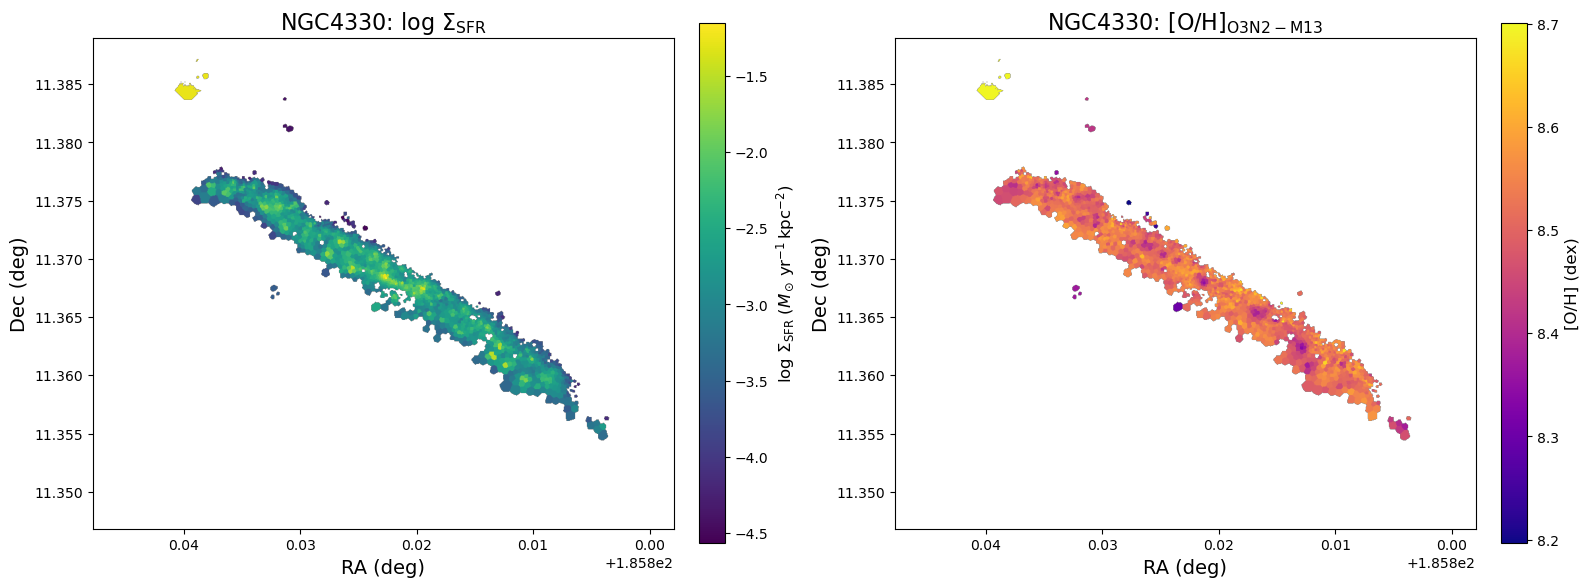

In [3]:
# ------------------------------------------------------------------
# 0.  Load NGC4330 maps and visualise Σ_SFR bins (6) + [O/H] bins (6, rainbow)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_sfr & valid_oh

    # ------------------------------------------------------------------
    # 2.  Define bin edges (match those used earlier in this notebook)
    # ------------------------------------------------------------------
    # Σ_SFR bins (6)
    n_sfr_bins = 6
    sfr_min, sfr_max = np.nanmin(sigSFR[valid_sfr]), np.nanmax(sigSFR[valid_sfr])
    sfr_bin_edges = np.linspace(sfr_min, sfr_max, n_sfr_bins + 1)
    colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_sfr_bins))

    # Metallicities bins (6 equal width, rainbow palette)
    n_oh_bins = 6
    oh_min, oh_max = np.nanmin(oh_o3n2_map[valid_oh]), np.nanmax(oh_o3n2_map[valid_oh])
    oh_bin_edges = np.linspace(oh_min, oh_max, n_oh_bins + 1)
    colors_oh = plt.cm.rainbow(np.linspace(0, 1, n_oh_bins))

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Build discrete maps for Σ_SFR bins (left) and [O/H] bins (right)
    # ------------------------------------------------------------------
    sfr_bin_map = np.full(sigSFR.shape, np.nan)
    oh_bin_map = np.full(oh_o3n2_map.shape, np.nan)

    for i in range(n_sfr_bins):
        lower, upper = sfr_bin_edges[i], sfr_bin_edges[i + 1]
        if i == n_sfr_bins - 1:
            mask = valid_sfr & (sigSFR >= lower) & (sigSFR <= upper)
        else:
            mask = valid_sfr & (sigSFR >= lower) & (sigSFR < upper)
        sfr_bin_map[mask] = i

    for i in range(n_oh_bins):
        lower, upper = oh_bin_edges[i], oh_bin_edges[i + 1]
        if i == n_oh_bins - 1:
            mask = valid_oh & (oh_o3n2_map >= lower) & (oh_o3n2_map <= upper)
        else:
            mask = valid_oh & (oh_o3n2_map >= lower) & (oh_o3n2_map < upper)
        oh_bin_map[mask] = i

    # ------------------------------------------------------------------
    # 5.  Create figure: left = Σ_SFR continuous, right = [O/H] continuous
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR continuous colormap
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sigSFR), origin='lower', cmap='viridis',
                            extent=extent)
    axes[0].set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)

    # Right-hand side: [O/H] continuous colormap
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_o3n2_map), origin='lower', cmap='plasma',
                           extent=extent)
    axes[1].set_title(rf'{gal}: [O/H]$_{{\mathrm{{{indicator_name}}}}}$', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'[O/H] (dex)', fontsize=12)

    # For reporting: basic statistics for the maps
    print(f"\n[{indicator_name}] statistics for {gal}:")
    print(f"  Σ_SFR range: {np.nanmin(sigSFR[valid_sfr]):.3f} to {np.nanmax(sigSFR[valid_sfr]):.3f}")
    print(f"  [O/H] range: {np.nanmin(oh_o3n2_map[valid_oh]):.3f} to {np.nanmax(oh_o3n2_map[valid_oh]):.3f}")
    print(f"  Valid pixels for Σ_SFR: {np.sum(valid_sfr)}")
    print(f"  Valid pixels for [O/H]: {np.sum(valid_oh)}")
    print(f"  Common valid pixels: {np.sum(valid_all)}")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_maps_continuous.png', dpi=600)
    plt.show()



[O3N2-M13] offset statistics for NGC4330:
  Σ_SFR mean: -2.833
  Σ_SFR offset range: -1.734 to 1.677
  Σ_SFR offset max absolute: ±1.734
  [O/H] mean: 8.517
  [O/H] offset range: -0.321 to 0.183
  [O/H] offset max absolute: ±0.321
  Valid pixels for Σ_SFR: 42998
  Valid pixels for [O/H]: 42998
  Common valid pixels: 42998


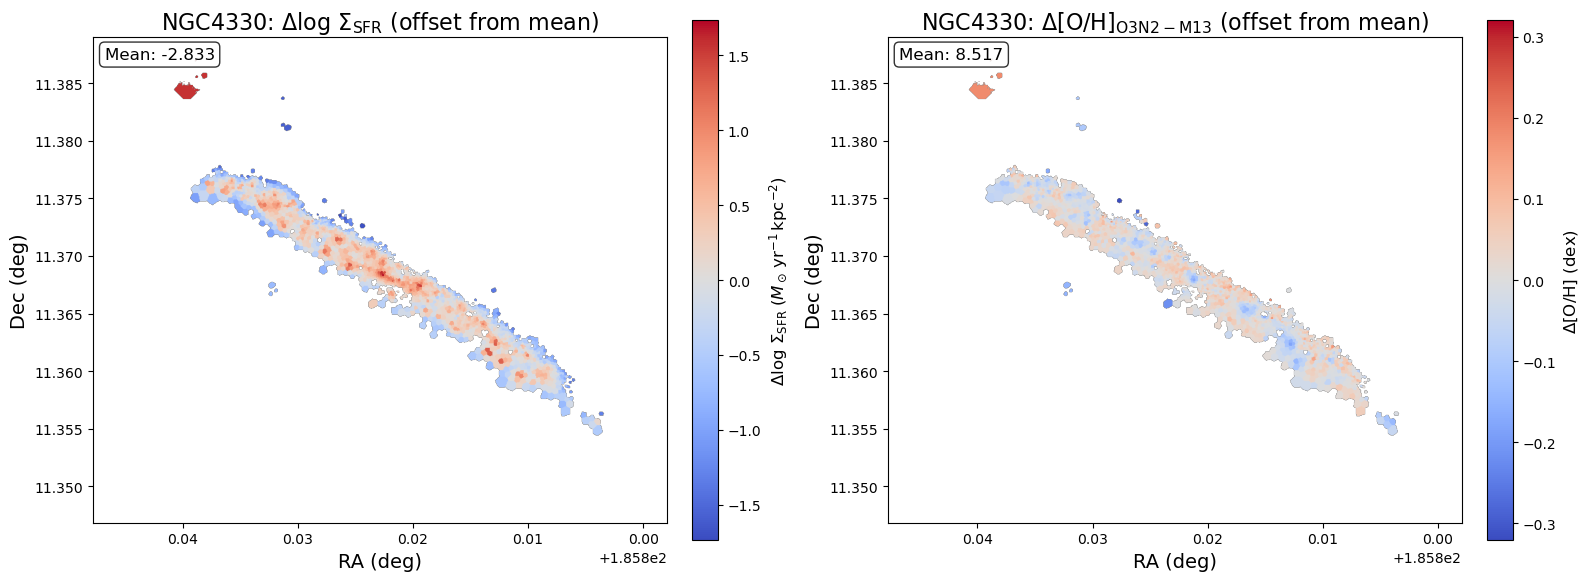

In [4]:
# ------------------------------------------------------------------
# 0.  Load NGC4330 maps and visualise Σ_SFR and [O/H] offset maps
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_sfr & valid_oh

    # ------------------------------------------------------------------
    # 2.  Calculate mean values and create offset maps
    # ------------------------------------------------------------------
    # Calculate mean values for offset calculation
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
    
    # Create offset maps (difference from mean)
    sfr_offset = sigSFR - sfr_mean
    oh_offset = oh_o3n2_map - oh_mean
    
    # Calculate symmetric colorbar limits for offset maps
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_sfr]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_oh]))

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Create figure: left = Σ_SFR offset, right = [O/H] offset
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR offset map (coolwarm, centered at 0)
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    axes[0].set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from mean)', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    
    # Add mean value annotation on top left
    axes[0].text(0.02, 0.98, f'Mean: {sfr_mean:.3f}', transform=axes[0].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Right-hand side: [O/H] offset map (coolwarm, centered at 0)
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                           extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    axes[1].set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from mean)', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=12)
    
    # Add mean value annotation on top left
    axes[1].text(0.02, 0.98, f'Mean: {oh_mean:.3f}', transform=axes[1].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # For reporting: offset statistics for the maps
    print(f"\n[{indicator_name}] offset statistics for {gal}:")
    print(f"  Σ_SFR mean: {sfr_mean:.3f}")
    print(f"  Σ_SFR offset range: {np.nanmin(sfr_offset[valid_sfr]):.3f} to {np.nanmax(sfr_offset[valid_sfr]):.3f}")
    print(f"  Σ_SFR offset max absolute: ±{sfr_offset_max:.3f}")
    print(f"  [O/H] mean: {oh_mean:.3f}")
    print(f"  [O/H] offset range: {np.nanmin(oh_offset[valid_oh]):.3f} to {np.nanmax(oh_offset[valid_oh]):.3f}")
    print(f"  [O/H] offset max absolute: ±{oh_offset_max:.3f}")
    print(f"  Valid pixels for Σ_SFR: {np.sum(valid_sfr)}")
    print(f"  Valid pixels for [O/H]: {np.sum(valid_oh)}")
    print(f"  Common valid pixels: {np.sum(valid_all)}")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_offset_maps.png', dpi=600)
    plt.show()

Creating Δ[O/H] vs ΔΣSFR scatter plot for NGC4330...
Valid pixels: 42998
ΔΣSFR range: -1.734 to 1.677
Δ[O/H] range: -0.321 to 0.183
Pearson correlation: r = 0.093, p = 7.687e-83 (N_unique = 1760)


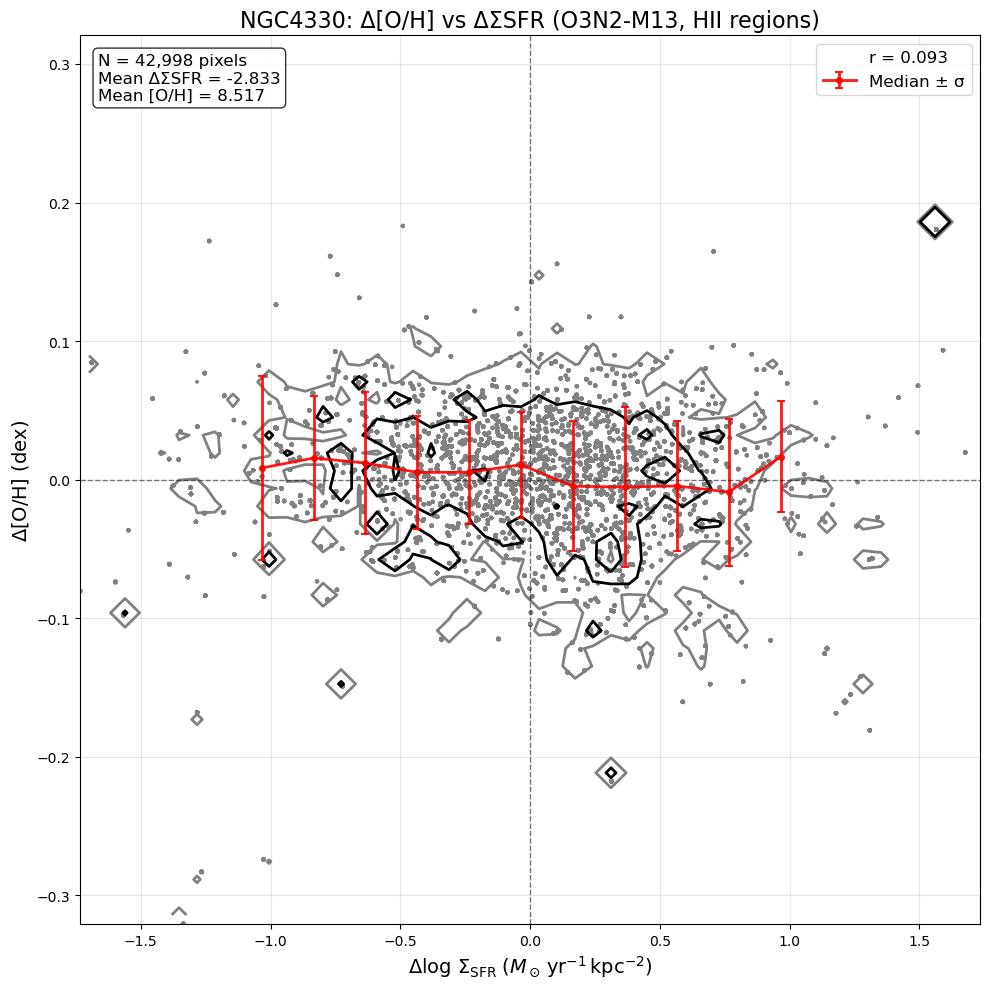


Plot complete!


In [5]:
# ------------------------------------------------------------------
# Plot Δ[O/H] vs ΔΣSFR for NGC4330 (all pixels combined)
# Origin centered at (0,0)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_sfr & valid_oh

    # ------------------------------------------------------------------
    # 2.  Calculate mean values and create offset maps
    # ------------------------------------------------------------------
    # Calculate mean values for offset calculation
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
    
    # Create offset maps (difference from mean)
    sfr_offset = sigSFR - sfr_mean
    oh_offset = oh_o3n2_map - oh_mean

    print("Creating Δ[O/H] vs ΔΣSFR scatter plot for NGC4330...")
    print(f"Valid pixels: {np.sum(valid_all)}")
    print(f"ΔΣSFR range: {np.nanmin(sfr_offset[valid_all]):.3f} to {np.nanmax(sfr_offset[valid_all]):.3f}")
    print(f"Δ[O/H] range: {np.nanmin(oh_offset[valid_all]):.3f} to {np.nanmax(oh_offset[valid_all]):.3f}")

    # Extract valid data points
    delta_sfr = sfr_offset[valid_all]
    delta_oh = oh_offset[valid_all]

    # Calculate Pearson correlation only if >= 20 unique data points
    n_unique = len(np.unique(np.column_stack([delta_sfr, delta_oh]), axis=0))
    pearson_r = None
    pearson_p = None
    if n_unique >= 20:
        pearson_r, pearson_p = pearsonr(delta_sfr, delta_oh)
        print(f"Pearson correlation: r = {pearson_r:.3f}, p = {pearson_p:.3e} (N_unique = {n_unique})")
    else:
        print(f"Insufficient unique data points for Pearson correlation (N_unique = {n_unique})")

    # Calculate symmetric axis limits to center the origin
    max_abs_sfr = np.nanmax(np.abs(delta_sfr))
    max_abs_oh = np.nanmax(np.abs(delta_oh))

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 10))

    # Scatter plot
    ax.scatter(delta_sfr, delta_oh, c='gray', s=10, alpha=0.5, edgecolors='none', rasterized=True)

    # Create 2D histogram for contours
    H, xedges, yedges = np.histogram2d(delta_sfr, delta_oh, bins=50,
                                       range=[[-max_abs_sfr, max_abs_sfr],
                                              [-max_abs_oh, max_abs_oh]])
    H = H.T  # Transpose for correct orientation
    
    # Calculate cumulative distribution for contour levels
    H_sorted = np.sort(H.flatten())[::-1]
    H_cumsum = np.cumsum(H_sorted)
    H_cumsum = H_cumsum / H_cumsum[-1]
    
    # Find levels for 68% and 95% (1σ and 2σ)
    level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
    level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]
    
    # Plot contours (ensure increasing order and different levels)
    X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
    if level_95 < level_68:
        levels_to_plot = [level_95, level_68]
        colors_to_plot = ['gray', 'black']
    elif level_95 > level_68:
        levels_to_plot = [level_68, level_95]
        colors_to_plot = ['black', 'gray']
    else:
        # If levels are equal, just plot one
        levels_to_plot = [level_68]
        colors_to_plot = ['black']
    
    if len(levels_to_plot) > 0:
        ax.contour(X, Y, H, levels=levels_to_plot, colors=colors_to_plot,
                  linewidths=[2] * len(levels_to_plot), alpha=1.0)
    
    # Calculate median trend with errorbars (reuse function from cell 6)
    def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
        """Calculate binned median and std for scatter data."""
        x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
        bins = np.arange(x_min, x_max + bin_width, bin_width)
        
        bin_centers = []
        medians = []
        stds = []
        counts = []
        
        for i in range(len(bins) - 1):
            mask = (x_data >= bins[i]) & (x_data < bins[i+1])
            y_in_bin = y_data[mask]
            
            # Only include bins with enough unique data points
            if len(np.unique(y_in_bin)) >= min_pixels:
                bin_centers.append((bins[i] + bins[i+1]) / 2)
                medians.append(np.nanmedian(y_in_bin))
                stds.append(np.nanstd(y_in_bin))
                counts.append(len(y_in_bin))
        
        return np.array(bin_centers), np.array(medians), np.array(stds), np.array(counts)
    
    bin_centers, medians, stds, counts = calculate_binned_stats(
        delta_sfr, delta_oh, bin_width=0.2, min_pixels=20)
    
    # Build legend entries
    legend_entries = []
    if len(bin_centers) > 0:
        ax.errorbar(bin_centers, medians, yerr=stds, fmt='o-', 
                   color='red', markersize=4, linewidth=2, capsize=3, 
                   capthick=1.5, alpha=0.9, label='Median ± σ')
        legend_entries.append('Median ± σ')
    
    # Add Pearson correlation as separate text in legend area if calculated
    if pearson_r is not None:
        # Add invisible line for legend entry
        ax.plot([], [], ' ', label=f'r = {pearson_r:.3f}')
    
    if len(legend_entries) > 0 or pearson_r is not None:
        ax.legend(loc='upper right', fontsize=12)

    # Set symmetric limits to center the origin
    ax.set_xlim(-max_abs_sfr, max_abs_sfr)
    ax.set_ylim(-max_abs_oh, max_abs_oh)

    # Add grid and center lines
    ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax.grid(True, alpha=0.3)

    # Labels
    ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)
    ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=14)
    ax.set_title(f'NGC4330: Δ[O/H] vs ΔΣSFR ({indicator_name}, HII regions)', fontsize=16)

    # Add statistics text box
    textstr = f'N = {len(delta_sfr):,} pixels\nMean ΔΣSFR = {sfr_mean:.3f}\nMean [O/H] = {oh_mean:.3f}'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    # plt.savefig('NGC4330_Delta_OH_vs_Delta_SigmaSFR.png', dpi=300, bbox_inches='tight')
    # plt.savefig('NGC4330_Delta_OH_vs_Delta_SigmaSFR.pdf', bbox_inches='tight')
    plt.show()

    print("\nPlot complete!")


Creating Δ[O/H] vs ΔΣSFR plots with contours and median trends...
Total valid pixels: 42998
Σ_* range: 6.135 to 8.400
  Bin 1: log(Σ*) = 6.13–6.32, N = 140, median bins = 0, N_unique = 1, r = N/A (insufficient unique points)
  Bin 3: log(Σ*) = 6.51–6.70, N = 136, median bins = 0, N_unique = 1, r = N/A (insufficient unique points)
  Bin 4: log(Σ*) = 6.70–6.89, N = 808, median bins = 0, N_unique = 10, r = N/A (insufficient unique points)
  Bin 5: log(Σ*) = 6.89–7.08, N = 3099, median bins = 0, N_unique = 48, r = -0.175
  Bin 6: log(Σ*) = 7.08–7.27, N = 7766, median bins = 5, N_unique = 202, r = -0.193
  Bin 7: log(Σ*) = 7.27–7.46, N = 10108, median bins = 7, N_unique = 383, r = -0.254
  Bin 8: log(Σ*) = 7.46–7.65, N = 10694, median bins = 6, N_unique = 487, r = -0.230
  Bin 9: log(Σ*) = 7.65–7.83, N = 6676, median bins = 6, N_unique = 340, r = 0.595
  Bin 10: log(Σ*) = 7.83–8.02, N = 2509, median bins = 4, N_unique = 181, r = -0.105
  Bin 11: log(Σ*) = 8.02–8.21, N = 799, median bins = 1

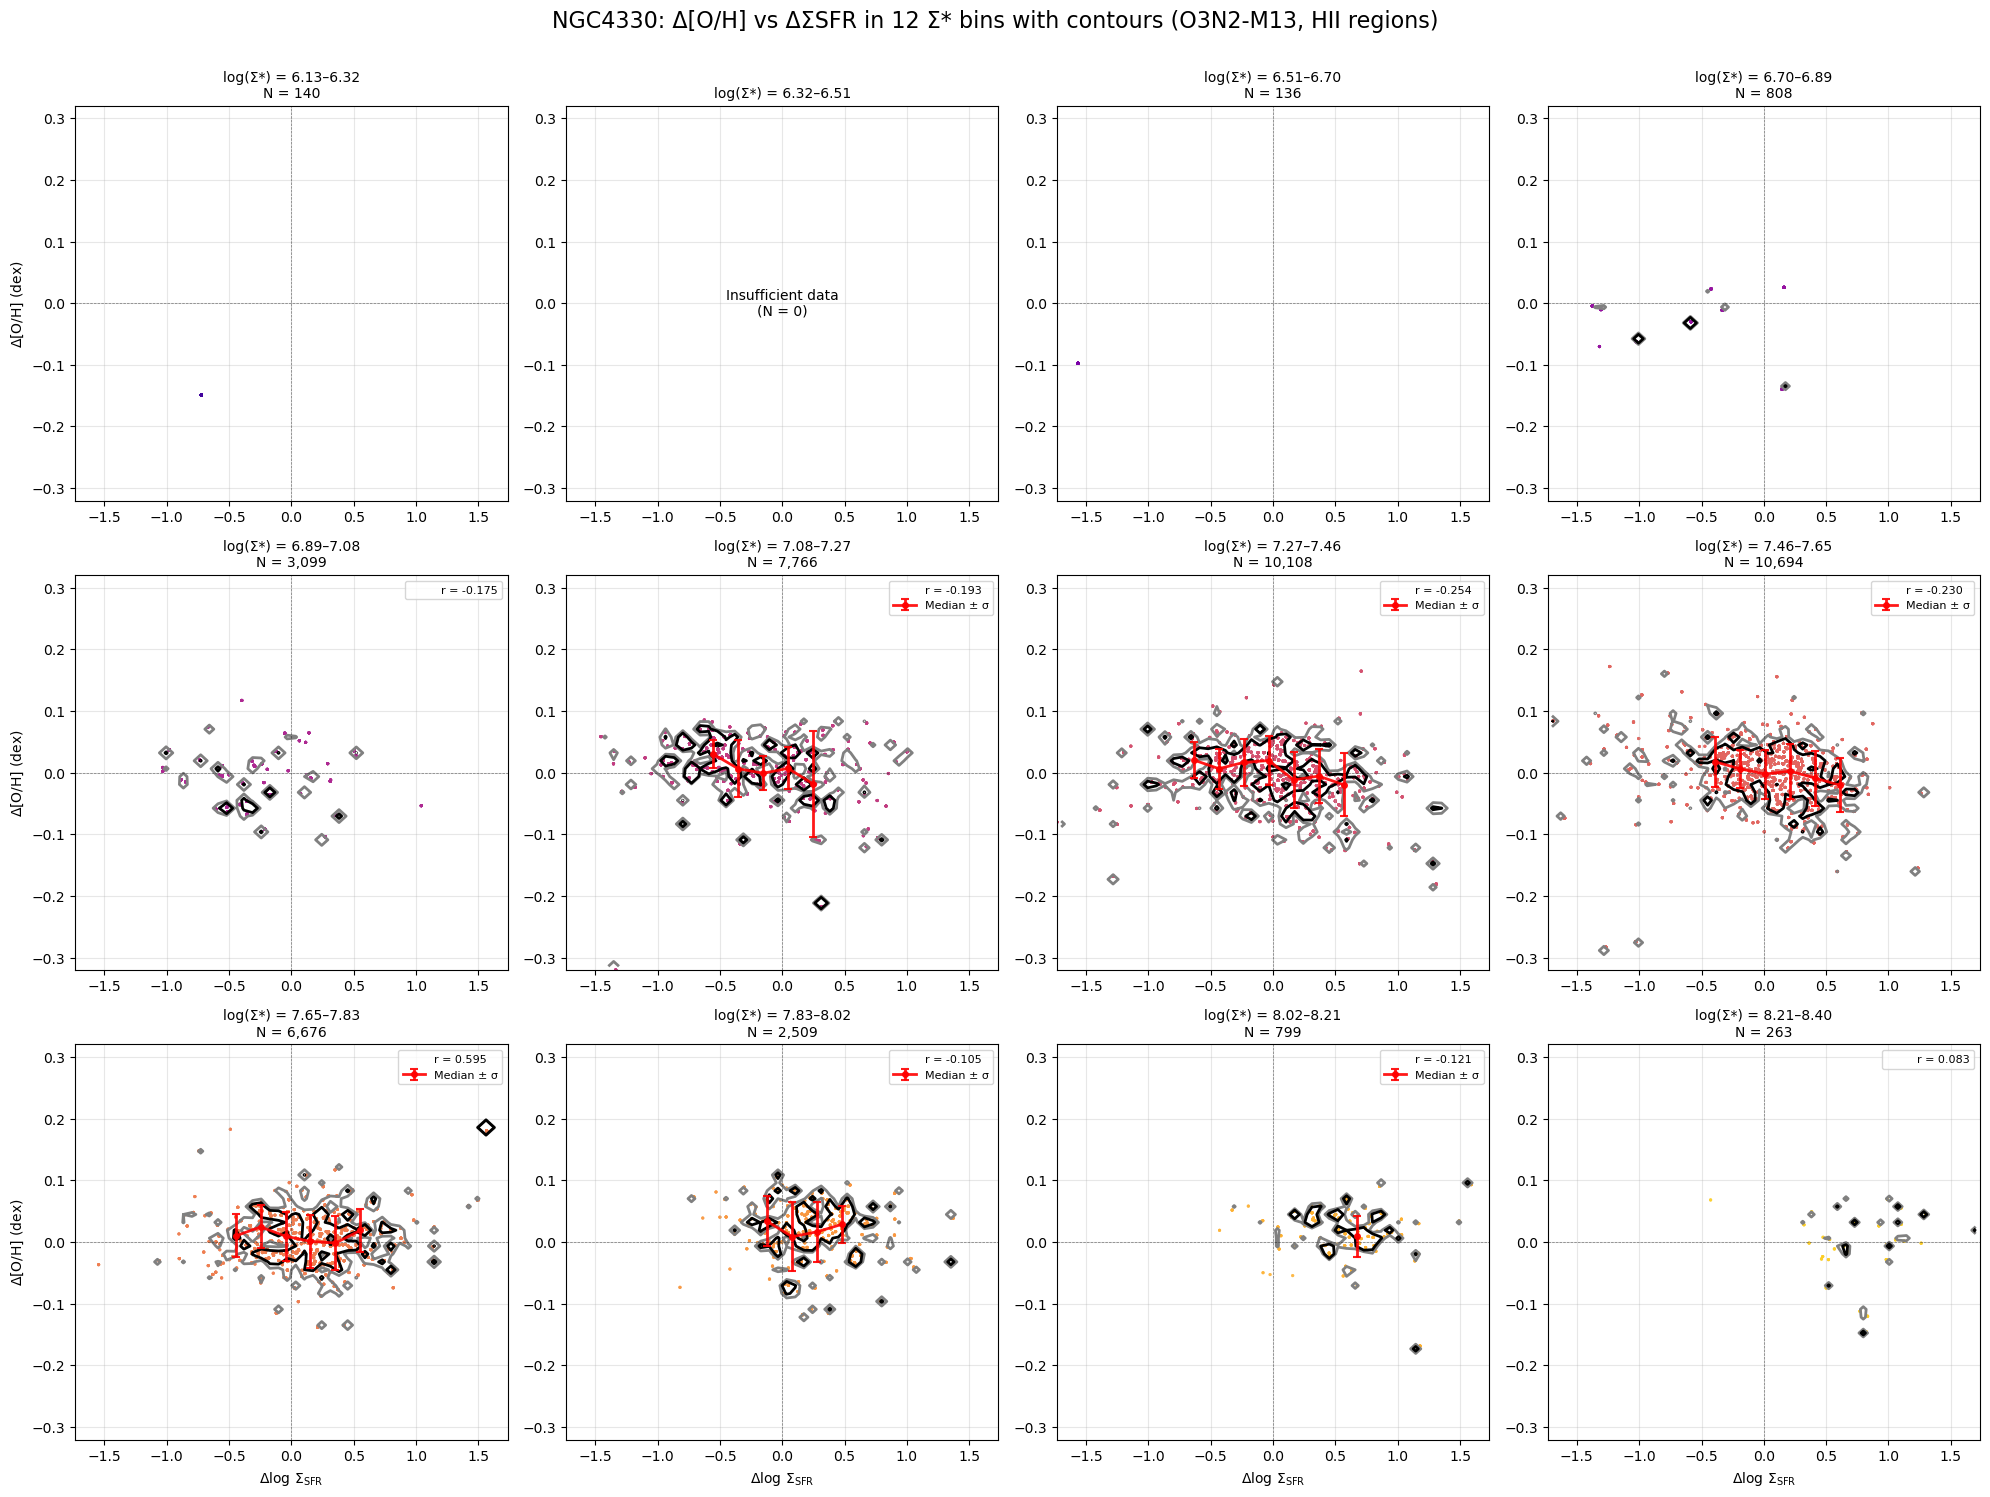


Plot complete!


In [6]:
# ------------------------------------------------------------------
# Plot Δ[O/H] vs ΔΣSFR for NGC4330 in 12 Σ* bins (4x3 subplots)
# With 68% and 95% contours, and median trends with errorbars
# Using the Σ* bin edges defined in cell 2 (from NGC4330 data)
# Origin centered at (0,0) in each subplot
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, pearsonr

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts))

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate mean values and create offset maps
    # ------------------------------------------------------------------
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
    
    sfr_offset = sigSFR - sfr_mean
    oh_offset = oh_o3n2_map - oh_mean

    # ------------------------------------------------------------------
    # 3.  Define 12 Σ* bins (based on pixels with ALL valid data)
    # ------------------------------------------------------------------
    n_bins_sigmaM = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)
    
    bin_labels_sigmaM = []
    for i in range(n_bins_sigmaM):
        bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')
    
    colors_sigmaM = plt.cm.plasma(np.linspace(0.1, 0.9, n_bins_sigmaM))

    print("Creating Δ[O/H] vs ΔΣSFR plots with contours and median trends...")
    print(f"Total valid pixels: {np.sum(valid_all)}")
    print(f"Σ_* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")

    sigM_valid = sigM[valid_all]
    delta_sfr_all = sfr_offset[valid_all]
    delta_oh_all = oh_offset[valid_all]

    max_abs_sfr_global = np.nanmax(np.abs(delta_sfr_all))
    max_abs_oh_global = np.nanmax(np.abs(delta_oh_all))

    # ------------------------------------------------------------------
    # 4.  Create 4x3 subplot figure
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    for i in range(n_bins_sigmaM):
        ax = axes[i]
        
        # Select pixels in this Σ* bin
        if i == 0:
            in_bin = (sigM_valid >= sigmaM_bin_edges[i]) & (sigM_valid < sigmaM_bin_edges[i+1])
        elif i == n_bins_sigmaM - 1:
            in_bin = (sigM_valid >= sigmaM_bin_edges[i]) & (sigM_valid <= sigmaM_bin_edges[i+1])
        else:
            in_bin = (sigM_valid >= sigmaM_bin_edges[i]) & (sigM_valid < sigmaM_bin_edges[i+1])
        
        n_pixels = np.sum(in_bin)
        
        if n_pixels >= 10:  # Show scatter if at least 10 points
            delta_sfr_bin = delta_sfr_all[in_bin]
            delta_oh_bin = delta_oh_all[in_bin]
            
            # Calculate Pearson correlation only if >= 20 unique data points
            n_unique = len(np.unique(np.column_stack([delta_sfr_bin, delta_oh_bin]), axis=0))
            pearson_r = None
            pearson_p = None
            if n_unique >= 20:
                pearson_r, pearson_p = pearsonr(delta_sfr_bin, delta_oh_bin)
            
            # Scatter plot with plasma color
            ax.scatter(delta_sfr_bin, delta_oh_bin, c=[colors_sigmaM[i]], s=5, alpha=0.5, 
                      edgecolors='none', rasterized=True)
            
            # Only create contours if enough points (>= 50)
            if n_pixels >= 50:
                # Create 2D histogram for contours
                H, xedges, yedges = np.histogram2d(delta_sfr_bin, delta_oh_bin, bins=50,
                                                   range=[[-max_abs_sfr_global, max_abs_sfr_global],
                                                          [-max_abs_oh_global, max_abs_oh_global]])
                H = H.T  # Transpose for correct orientation
                
                # Calculate cumulative distribution for contour levels
                H_sorted = np.sort(H.flatten())[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum = H_cumsum / H_cumsum[-1]
                
                # Find levels for 68% and 95% (1σ and 2σ)
                level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
                level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]
                
                # Plot contours (ensure increasing order and different levels)
                X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
                if level_95 < level_68:
                    levels_to_plot = [level_95, level_68]
                    colors_to_plot = ['gray', 'black']
                elif level_95 > level_68:
                    levels_to_plot = [level_68, level_95]
                    colors_to_plot = ['black', 'gray']
                else:
                    # If levels are equal, just plot one
                    levels_to_plot = [level_68]
                    colors_to_plot = ['black']
                
                if len(levels_to_plot) > 0:
                    ax.contour(X, Y, H, levels=levels_to_plot, colors=colors_to_plot,
                              linewidths=[2] * len(levels_to_plot), alpha=1.0)
            
            # Calculate median trend with errorbars
            bin_centers, medians, stds, counts = calculate_binned_stats(
                delta_sfr_bin, delta_oh_bin, bin_width=0.2, min_pixels=20)
            
            # Build legend entries
            legend_entries = []
            if len(bin_centers) > 0:
                ax.errorbar(bin_centers, medians, yerr=stds, fmt='o-', 
                           color='red', markersize=4, linewidth=2, capsize=3, 
                           capthick=1.5, alpha=0.9, label='Median ± σ')
                legend_entries.append('Median ± σ')
            
            # Add Pearson correlation as separate text in legend area if calculated
            if pearson_r is not None:
                # Add invisible line for legend entry
                ax.plot([], [], ' ', label=f'r = {pearson_r:.3f}')
            
            if len(legend_entries) > 0 or pearson_r is not None:
                ax.legend(loc='upper right', fontsize=8)
            
            # Set limits and styling
            ax.set_xlim(-max_abs_sfr_global, max_abs_sfr_global)
            ax.set_ylim(-max_abs_oh_global, max_abs_oh_global)
            
            # Add grid and center lines
            ax.axhline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
            ax.axvline(0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
            
            ax.grid(True, alpha=0.3)
            
            bin_label = bin_labels_sigmaM[i]
            ax.set_title(f'log(Σ*) = {bin_label}\nN = {n_pixels:,}', fontsize=10)
            
            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=10)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=10)
            
            # Print statistics
            pearson_str = f", r = {pearson_r:.3f}" if pearson_r is not None else ", r = N/A (insufficient unique points)"
            print(f"  Bin {i+1}: log(Σ*) = {bin_label}, N = {n_pixels}, median bins = {len(bin_centers)}, N_unique = {n_unique}{pearson_str}")
        else:
            # Not enough pixels
            ax.text(0.5, 0.5, f'Insufficient data\n(N = {n_pixels})', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_xlim(-max_abs_sfr_global, max_abs_sfr_global)
            ax.set_ylim(-max_abs_oh_global, max_abs_oh_global)
            ax.grid(True, alpha=0.3)
            bin_label = bin_labels_sigmaM[i]
            ax.set_title(f'log(Σ*) = {bin_label}', fontsize=10)
            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=10)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=10)

    fig.suptitle(f'NGC4330: Δ[O/H] vs ΔΣSFR in 12 Σ* bins with contours ({indicator_name}, HII regions)', 
                 fontsize=16, y=0.995)

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    # plt.savefig('NGC4330_Delta_OH_vs_Delta_SigmaSFR_12massbins_contours.png', dpi=300, bbox_inches='tight')
    # plt.savefig('NGC4330_Delta_OH_vs_Delta_SigmaSFR_12massbins_contours.pdf', bbox_inches='tight')
    plt.show()

    print("\nPlot complete!")


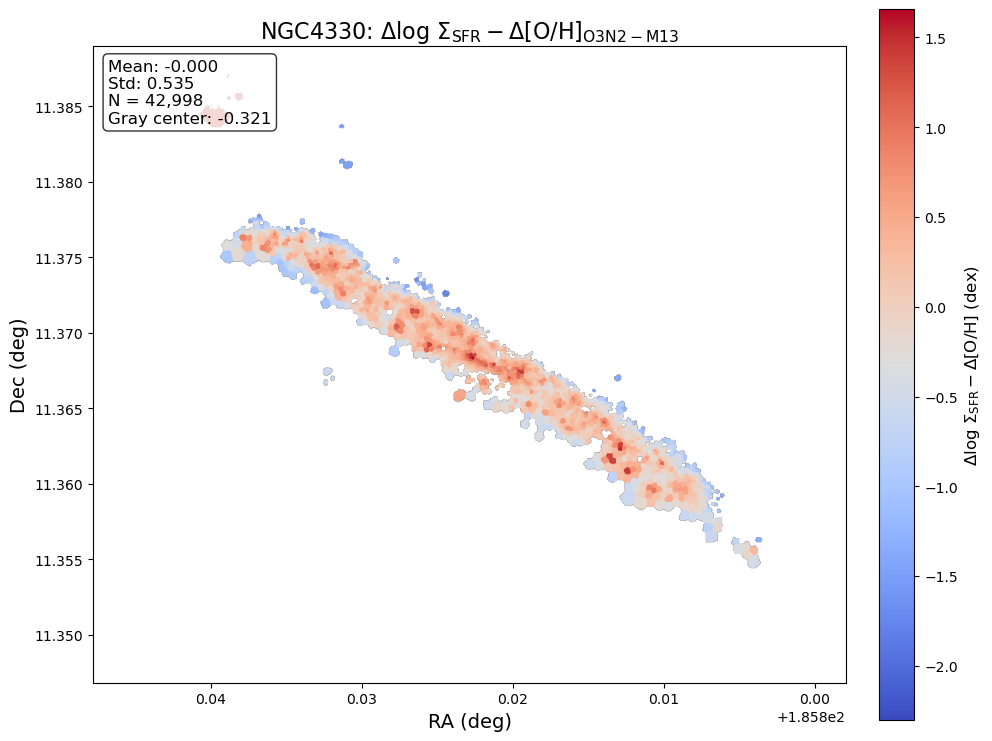


Difference map complete!
Range: -1.773 to 1.658
Colorbar centered at: -0.321 (gray = ΔΣSFR = Δ[O/H])
Max |Δ[O/H]|: 0.321


In [7]:
# ------------------------------------------------------------------
# Plot the difference map: (ΔΣSFR - Δ[O/H])
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_sfr & valid_oh

    # ------------------------------------------------------------------
    # 2.  Calculate mean values and create offset maps
    # ------------------------------------------------------------------
    # Calculate mean values for offset calculation
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
    
    # Create offset maps (difference from mean)
    sfr_offset = sigSFR - sfr_mean
    oh_offset = oh_o3n2_map - oh_mean
    
    # Calculate the difference map: ΔΣSFR - Δ[O/H]
    difference_map = sfr_offset - oh_offset
    
    # Calculate colorbar limits: center at -abs(max(Δ[O/H]))
    # So gray (0) represents where ΔΣSFR = Δ[O/H]
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_oh]))
    vmin_centered = -oh_offset_max
    vmax_centered = np.nanmax(difference_map[valid_all]) + oh_offset_max
    
    # Make symmetric around the centered zero point
    center_offset = -oh_offset_max
    max_range = max(abs(np.nanmin(difference_map[valid_all]) - center_offset),
                    abs(np.nanmax(difference_map[valid_all]) - center_offset))
    vmin_plot = center_offset - max_range
    vmax_plot = center_offset + max_range

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Create figure with the difference map
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 8))

    # Display the difference map (coolwarm, centered so gray = -oh_offset_max)
    im = ax.imshow(np.ma.masked_invalid(difference_map), origin='lower', cmap='coolwarm',
                   extent=extent, vmin=vmin_plot, vmax=vmax_plot)
    ax.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}} - \Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$', fontsize=16)
    ax.set_xlabel('RA (deg)', fontsize=14)
    ax.set_ylabel('Dec (deg)', fontsize=14)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} - \Delta$[O/H] (dex)', fontsize=12)
    
    # Add statistics annotation
    diff_mean = np.nanmean(difference_map[valid_all])
    diff_std = np.nanstd(difference_map[valid_all])
    textstr = f'Mean: {diff_mean:.3f}\nStd: {diff_std:.3f}\nN = {np.sum(valid_all):,}\nGray center: {center_offset:.3f}'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    # plt.savefig(f'{gal}_DeltaSFR_minus_DeltaOH.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{gal}_DeltaSFR_minus_DeltaOH.pdf', bbox_inches='tight')
    plt.show()

    print(f"\nDifference map complete!")
    print(f"Range: {np.nanmin(difference_map[valid_all]):.3f} to {np.nanmax(difference_map[valid_all]):.3f}")
    print(f"Colorbar centered at: {center_offset:.3f} (gray = ΔΣSFR = Δ[O/H])")
    print(f"Max |Δ[O/H]|: {oh_offset_max:.3f}")



[O3N2-M13] offset statistics for NGC4330:
  Σ_SFR minimum: -4.567
  Σ_SFR offset range: 0.000 to 3.411
  Σ_SFR offset max: 3.411
  [O/H] minimum: 8.197
  [O/H] offset range: 0.000 to 0.504
  [O/H] offset max: 0.504
  Valid pixels for Σ_SFR: 42998
  Valid pixels for [O/H]: 42998
  Common valid pixels: 42998


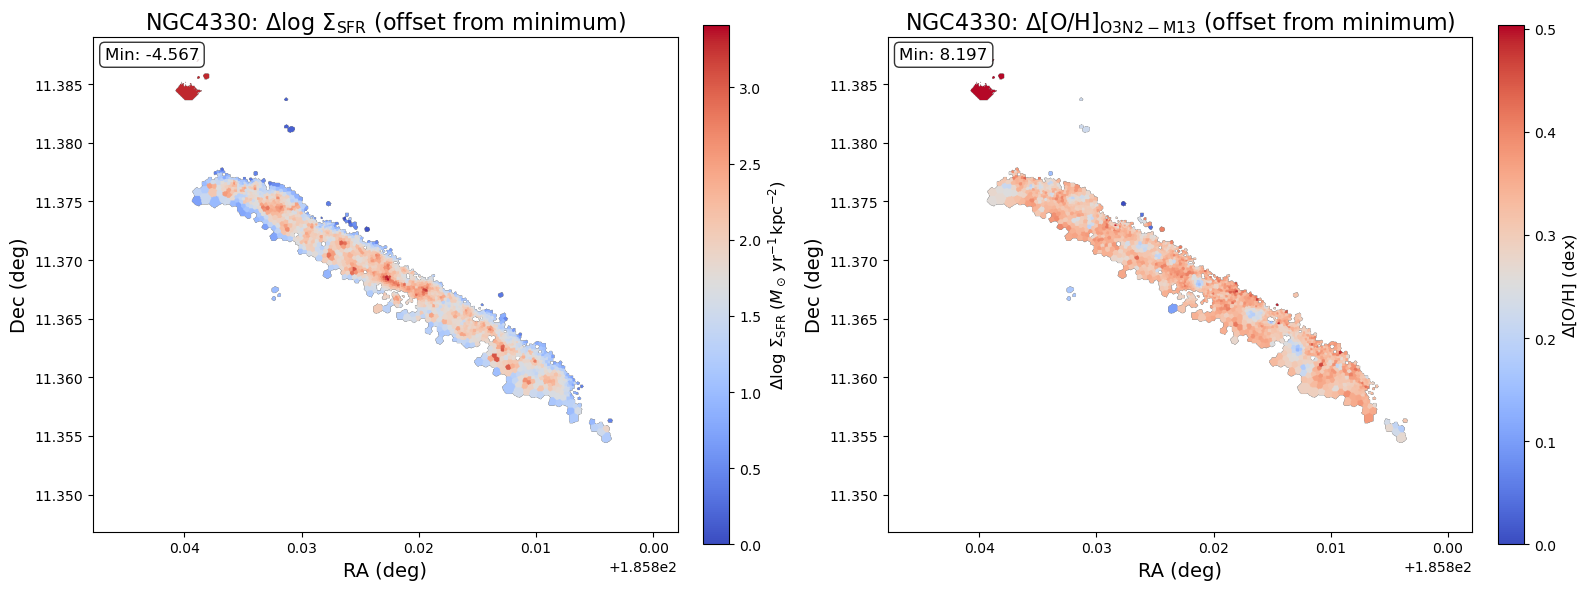

In [8]:
# ------------------------------------------------------------------
# 0.  Load NGC4330 maps and visualise Σ_SFR and [O/H] offset maps
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_sfr & valid_oh

    # ------------------------------------------------------------------
    # 2.  Calculate minimum values and create offset maps
    # ------------------------------------------------------------------
    # Calculate minimum values for offset calculation
    sfr_min = np.nanmin(sigSFR[valid_sfr])
    oh_min = np.nanmin(oh_o3n2_map[valid_oh])
    
    # Create offset maps (difference from minimum)
    sfr_offset = sigSFR - sfr_min
    oh_offset = oh_o3n2_map - oh_min
    
    # Calculate colorbar limits for offset maps (from 0 to max)
    sfr_offset_max = np.nanmax(sfr_offset[valid_sfr])
    oh_offset_max = np.nanmax(oh_offset[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Create figure: left = Σ_SFR offset, right = [O/H] offset
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR offset map (coolwarm, from 0 to max)
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=0, vmax=sfr_offset_max)
    axes[0].set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from minimum)', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    
    # Add minimum value annotation on top left
    axes[0].text(0.02, 0.98, f'Min: {sfr_min:.3f}', transform=axes[0].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Right-hand side: [O/H] offset map (coolwarm, from 0 to max)
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                           extent=extent, vmin=0, vmax=oh_offset_max)
    axes[1].set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from minimum)', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=12)
    
    # Add minimum value annotation on top left
    axes[1].text(0.02, 0.98, f'Min: {oh_min:.3f}', transform=axes[1].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # For reporting: offset statistics for the maps
    print(f"\n[{indicator_name}] offset statistics for {gal}:")
    print(f"  Σ_SFR minimum: {sfr_min:.3f}")
    print(f"  Σ_SFR offset range: {np.nanmin(sfr_offset[valid_sfr]):.3f} to {np.nanmax(sfr_offset[valid_sfr]):.3f}")
    print(f"  Σ_SFR offset max: {sfr_offset_max:.3f}")
    print(f"  [O/H] minimum: {oh_min:.3f}")
    print(f"  [O/H] offset range: {np.nanmin(oh_offset[valid_oh]):.3f} to {np.nanmax(oh_offset[valid_oh]):.3f}")
    print(f"  [O/H] offset max: {oh_offset_max:.3f}")
    print(f"  Valid pixels for Σ_SFR: {np.sum(valid_sfr)}")
    print(f"  Valid pixels for [O/H]: {np.sum(valid_oh)}")
    print(f"  Common valid pixels: {np.sum(valid_all)}")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_offset_maps_from_min.png', dpi=600)
    plt.show()


Creating Δ[O/H] vs ΔΣSFR scatter plot for NGC4330 (offsets from minimum)...
Valid pixels: 42998
ΔΣSFR range: 0.000 to 3.411
Δ[O/H] range: 0.000 to 0.504


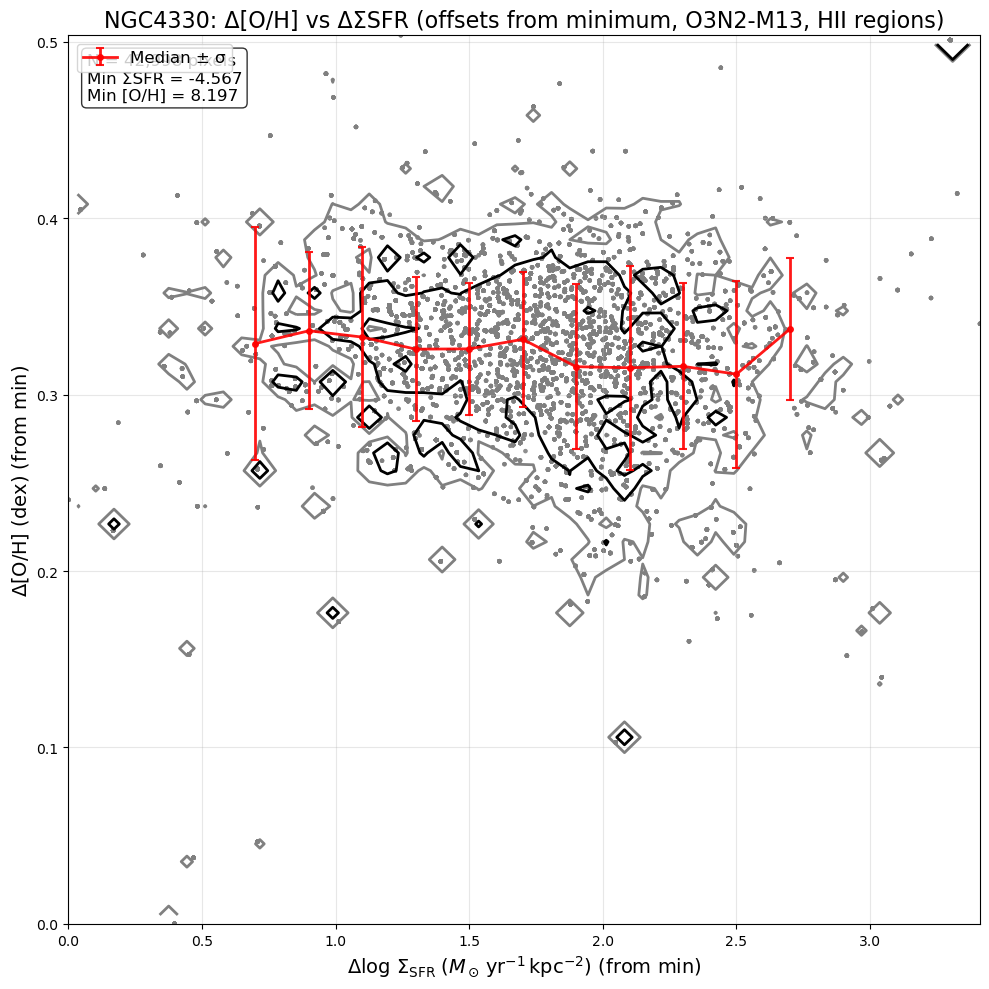


Plot complete!


In [9]:
# ------------------------------------------------------------------
# Plot Δ[O/H] vs ΔΣSFR for NGC4330 (all pixels combined)
# Offsets calculated from minimum values
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_sfr & valid_oh

    # ------------------------------------------------------------------
    # 2.  Calculate minimum values and create offset maps
    # ------------------------------------------------------------------
    # Calculate minimum values for offset calculation
    sfr_min = np.nanmin(sigSFR[valid_sfr])
    oh_min = np.nanmin(oh_o3n2_map[valid_oh])
    
    # Create offset maps (difference from minimum)
    sfr_offset = sigSFR - sfr_min
    oh_offset = oh_o3n2_map - oh_min

    print("Creating Δ[O/H] vs ΔΣSFR scatter plot for NGC4330 (offsets from minimum)...")
    print(f"Valid pixels: {np.sum(valid_all)}")
    print(f"ΔΣSFR range: {np.nanmin(sfr_offset[valid_all]):.3f} to {np.nanmax(sfr_offset[valid_all]):.3f}")
    print(f"Δ[O/H] range: {np.nanmin(oh_offset[valid_all]):.3f} to {np.nanmax(oh_offset[valid_all]):.3f}")

    # Extract valid data points
    delta_sfr = sfr_offset[valid_all]
    delta_oh = oh_offset[valid_all]

    # Calculate axis limits (from 0 to max since we're using minimum as reference)
    max_sfr = np.nanmax(delta_sfr)
    max_oh = np.nanmax(delta_oh)

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 10))

    # Scatter plot
    ax.scatter(delta_sfr, delta_oh, c='gray', s=10, alpha=0.5, edgecolors='none', rasterized=True)

    # Create 2D histogram for contours
    H, xedges, yedges = np.histogram2d(delta_sfr, delta_oh, bins=50,
                                       range=[[0, max_sfr],
                                              [0, max_oh]])
    H = H.T  # Transpose for correct orientation
    
    # Calculate cumulative distribution for contour levels
    H_sorted = np.sort(H.flatten())[::-1]
    H_cumsum = np.cumsum(H_sorted)
    H_cumsum = H_cumsum / H_cumsum[-1]
    
    # Find levels for 68% and 95% (1σ and 2σ)
    level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
    level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]
    
    # Plot contours (ensure increasing order and different levels)
    X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
    if level_95 < level_68:
        levels_to_plot = [level_95, level_68]
        colors_to_plot = ['gray', 'black']
    elif level_95 > level_68:
        levels_to_plot = [level_68, level_95]
        colors_to_plot = ['black', 'gray']
    else:
        # If levels are equal, just plot one
        levels_to_plot = [level_68]
        colors_to_plot = ['black']
    
    if len(levels_to_plot) > 0:
        ax.contour(X, Y, H, levels=levels_to_plot, colors=colors_to_plot,
                  linewidths=[2] * len(levels_to_plot), alpha=1.0)
    
    # Calculate median trend with errorbars
    def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
        """Calculate binned median and std for scatter data."""
        x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
        bins = np.arange(x_min, x_max + bin_width, bin_width)
        
        bin_centers = []
        medians = []
        stds = []
        counts = []
        
        for i in range(len(bins) - 1):
            mask = (x_data >= bins[i]) & (x_data < bins[i+1])
            y_in_bin = y_data[mask]
            
            # Only include bins with enough unique data points
            if len(np.unique(y_in_bin)) >= min_pixels:
                bin_centers.append((bins[i] + bins[i+1]) / 2)
                medians.append(np.nanmedian(y_in_bin))
                stds.append(np.nanstd(y_in_bin))
                counts.append(len(y_in_bin))
        
        return np.array(bin_centers), np.array(medians), np.array(stds), np.array(counts)
    
    bin_centers, medians, stds, counts = calculate_binned_stats(
        delta_sfr, delta_oh, bin_width=0.2, min_pixels=20)
    
    if len(bin_centers) > 0:
        ax.errorbar(bin_centers, medians, yerr=stds, fmt='o-', 
                   color='red', markersize=4, linewidth=2, capsize=3, 
                   capthick=1.5, alpha=0.9, label='Median ± σ')
        ax.legend(loc='upper left', fontsize=12)

    # Set limits (from 0 to max)
    ax.set_xlim(0, max_sfr)
    ax.set_ylim(0, max_oh)

    # Add grid
    ax.grid(True, alpha=0.3)

    # Labels
    ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$ (from min)', fontsize=14)
    ax.set_ylabel(r'$\Delta$[O/H] (dex) (from min)', fontsize=14)
    ax.set_title(f'NGC4330: Δ[O/H] vs ΔΣSFR (offsets from minimum, {indicator_name}, HII regions)', fontsize=16)

    # Add statistics text box
    textstr = f'N = {len(delta_sfr):,} pixels\nMin ΣSFR = {sfr_min:.3f}\nMin [O/H] = {oh_min:.3f}'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    # plt.savefig('NGC4330_Delta_OH_vs_Delta_SigmaSFR_from_min.png', dpi=300, bbox_inches='tight')
    # plt.savefig('NGC4330_Delta_OH_vs_Delta_SigmaSFR_from_min.pdf', bbox_inches='tight')
    plt.show()

    print("\nPlot complete!")


Creating Δ[O/H] vs ΔΣSFR plots (offsets from minimum) with contours and median trends...
Total valid pixels: 42998
Σ_* range: 6.135 to 8.400
Min ΣSFR: -4.567, Min [O/H]: 8.197
  Bin 1: log(Σ*) = 6.13–6.32, N = 140, median bins = 0
  Bin 3: log(Σ*) = 6.51–6.70, N = 136, median bins = 0
  Bin 4: log(Σ*) = 6.70–6.89, N = 808, median bins = 0
  Bin 5: log(Σ*) = 6.89–7.08, N = 3099, median bins = 0
  Bin 6: log(Σ*) = 7.08–7.27, N = 7766, median bins = 5
  Bin 7: log(Σ*) = 7.27–7.46, N = 10108, median bins = 7
  Bin 8: log(Σ*) = 7.46–7.65, N = 10694, median bins = 6
  Bin 9: log(Σ*) = 7.65–7.83, N = 6676, median bins = 6
  Bin 10: log(Σ*) = 7.83–8.02, N = 2509, median bins = 4
  Bin 11: log(Σ*) = 8.02–8.21, N = 799, median bins = 1
  Bin 12: log(Σ*) = 8.21–8.40, N = 263, median bins = 0


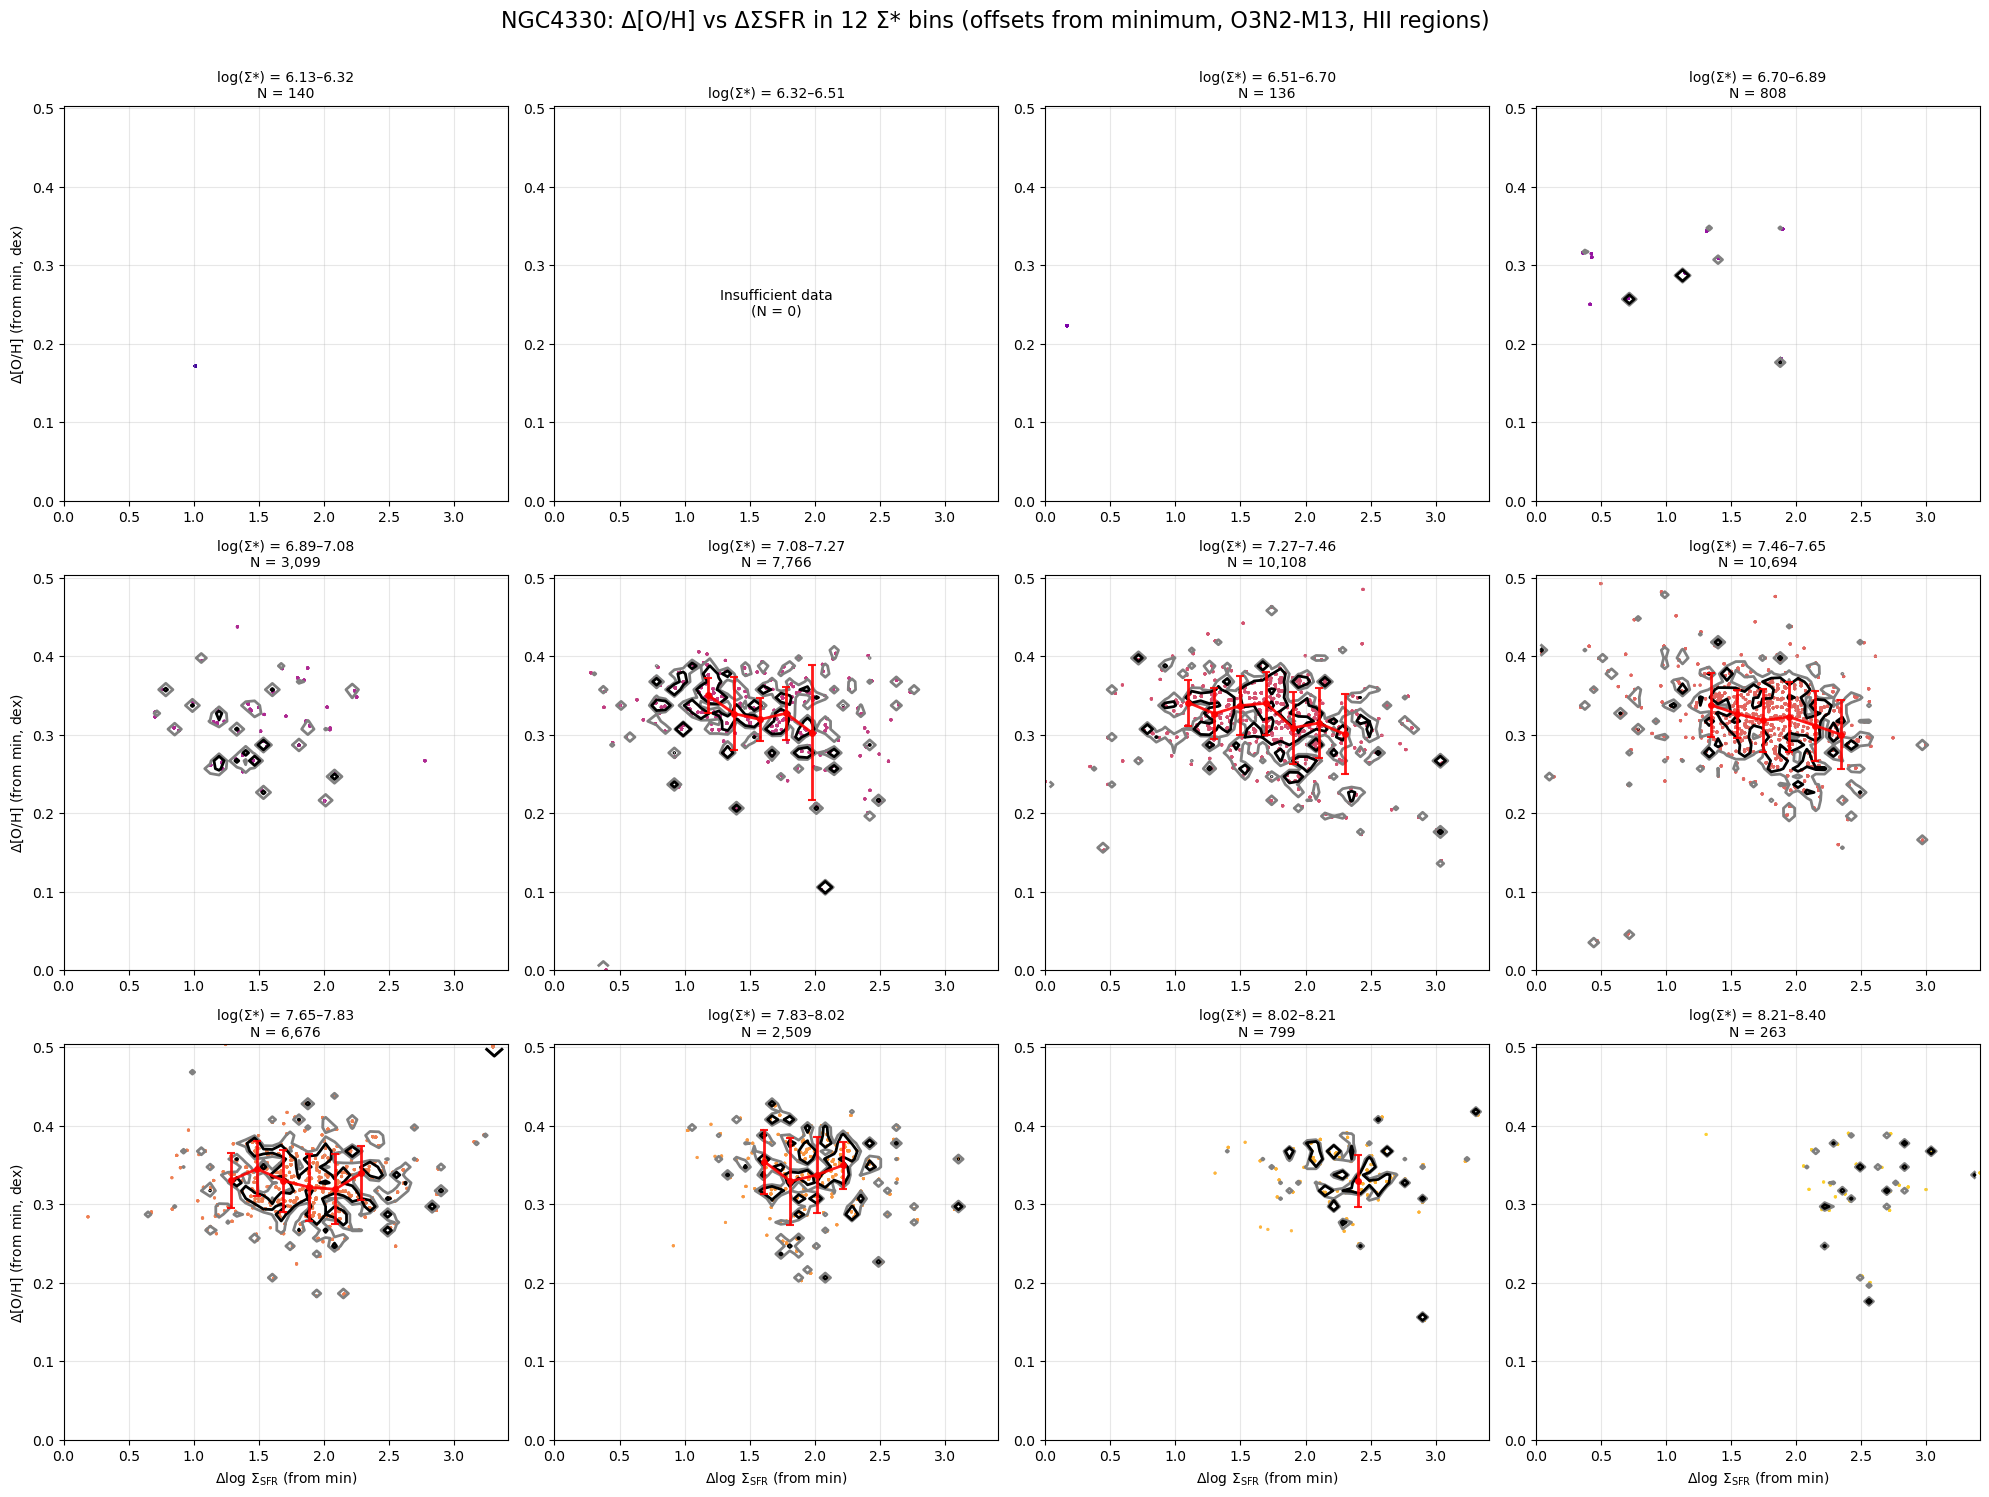


Plot complete!


In [10]:
# ------------------------------------------------------------------
# Plot Δ[O/H] vs ΔΣSFR for NGC4330 in 12 Σ* bins (4x3 subplots)
# With 68% and 95% contours, and median trends with errorbars
# Offsets calculated from minimum values (not mean)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts))

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate minimum values and create offset maps
    # ------------------------------------------------------------------
    sfr_min = np.nanmin(sigSFR[valid_sfr])
    oh_min = np.nanmin(oh_o3n2_map[valid_oh])
    
    sfr_offset = sigSFR - sfr_min
    oh_offset = oh_o3n2_map - oh_min

    # ------------------------------------------------------------------
    # 3.  Define 12 Σ* bins (based on pixels with ALL valid data)
    # ------------------------------------------------------------------
    n_bins_sigmaM = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)
    
    bin_labels_sigmaM = []
    for i in range(n_bins_sigmaM):
        bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')
    
    colors_sigmaM = plt.cm.plasma(np.linspace(0.1, 0.9, n_bins_sigmaM))

    print("Creating Δ[O/H] vs ΔΣSFR plots (offsets from minimum) with contours and median trends...")
    print(f"Total valid pixels: {np.sum(valid_all)}")
    print(f"Σ_* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"Min ΣSFR: {sfr_min:.3f}, Min [O/H]: {oh_min:.3f}")

    sigM_valid = sigM[valid_all]
    delta_sfr_all = sfr_offset[valid_all]
    delta_oh_all = oh_offset[valid_all]

    max_sfr_global = np.nanmax(delta_sfr_all)
    max_oh_global = np.nanmax(delta_oh_all)

    # ------------------------------------------------------------------
    # 4.  Create 4x3 subplot figure
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    for i in range(n_bins_sigmaM):
        ax = axes[i]
        
        # Select pixels in this Σ* bin
        if i == 0:
            in_bin = (sigM_valid >= sigmaM_bin_edges[i]) & (sigM_valid < sigmaM_bin_edges[i+1])
        elif i == n_bins_sigmaM - 1:
            in_bin = (sigM_valid >= sigmaM_bin_edges[i]) & (sigM_valid <= sigmaM_bin_edges[i+1])
        else:
            in_bin = (sigM_valid >= sigmaM_bin_edges[i]) & (sigM_valid < sigmaM_bin_edges[i+1])
        
        n_pixels = np.sum(in_bin)
        
        if n_pixels >= 10:  # Show scatter if at least 10 points
            delta_sfr_bin = delta_sfr_all[in_bin]
            delta_oh_bin = delta_oh_all[in_bin]
            
            # Scatter plot with plasma color
            ax.scatter(delta_sfr_bin, delta_oh_bin, c=[colors_sigmaM[i]], s=5, alpha=0.5, 
                      edgecolors='none', rasterized=True)
            
            # Only create contours if enough points (>= 50)
            if n_pixels >= 50:
                # Create 2D histogram for contours
                H, xedges, yedges = np.histogram2d(delta_sfr_bin, delta_oh_bin, bins=50,
                                                   range=[[0, max_sfr_global],
                                                          [0, max_oh_global]])
                H = H.T  # Transpose for correct orientation
                
                # Calculate cumulative distribution for contour levels
                H_sorted = np.sort(H.flatten())[::-1]
                H_cumsum = np.cumsum(H_sorted)
                H_cumsum = H_cumsum / H_cumsum[-1]
                
                # Find levels for 68% and 95% (1σ and 2σ)
                level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
                level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]
                
                # Plot contours (ensure increasing order and different levels)
                X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
                if level_95 < level_68:
                    levels_to_plot = [level_95, level_68]
                    colors_to_plot = ['gray', 'black']
                elif level_95 > level_68:
                    levels_to_plot = [level_68, level_95]
                    colors_to_plot = ['black', 'gray']
                else:
                    # If levels are equal, just plot one
                    levels_to_plot = [level_68]
                    colors_to_plot = ['black']
                
                if len(levels_to_plot) > 0:
                    ax.contour(X, Y, H, levels=levels_to_plot, colors=colors_to_plot,
                              linewidths=[2] * len(levels_to_plot), alpha=1.0)
            
            # Calculate median trend with errorbars
            bin_centers, medians, stds, counts = calculate_binned_stats(
                delta_sfr_bin, delta_oh_bin, bin_width=0.2, min_pixels=20)
            
            if len(bin_centers) > 0:
                ax.errorbar(bin_centers, medians, yerr=stds, fmt='o-', 
                           color='red', markersize=4, linewidth=2, capsize=3, 
                           capthick=1.5, alpha=0.9, label='Median ± σ')
            
            # Set limits (from 0 to max)
            ax.set_xlim(0, max_sfr_global)
            ax.set_ylim(0, max_oh_global)
            
            # Add grid
            ax.grid(True, alpha=0.3)
            
            bin_label = bin_labels_sigmaM[i]
            ax.set_title(f'log(Σ*) = {bin_label}\nN = {n_pixels:,}', fontsize=10)
            
            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (from min, dex)', fontsize=10)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (from min)', fontsize=10)
            
            print(f"  Bin {i+1}: log(Σ*) = {bin_label}, N = {n_pixels}, median bins = {len(bin_centers)}")
        else:
            # Not enough pixels
            ax.text(0.5, 0.5, f'Insufficient data\n(N = {n_pixels})', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_xlim(0, max_sfr_global)
            ax.set_ylim(0, max_oh_global)
            ax.grid(True, alpha=0.3)
            bin_label = bin_labels_sigmaM[i]
            ax.set_title(f'log(Σ*) = {bin_label}', fontsize=10)
            if i % 4 == 0:
                ax.set_ylabel(r'$\Delta$[O/H] (from min, dex)', fontsize=10)
            if i >= 8:
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (from min)', fontsize=10)

    fig.suptitle(f'NGC4330: Δ[O/H] vs ΔΣSFR in 12 Σ* bins (offsets from minimum, {indicator_name}, HII regions)', 
                 fontsize=16, y=0.995)

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    # plt.savefig('NGC4330_Delta_OH_vs_Delta_SigmaSFR_12massbins_from_min.png', dpi=300, bbox_inches='tight')
    # plt.savefig('NGC4330_Delta_OH_vs_Delta_SigmaSFR_12massbins_from_min.pdf', bbox_inches='tight')
    plt.show()

    print("\nPlot complete!")


## 20251016 define the slope
We want to define the slope in the relation, no matter if it is $\mathrm{[O/H]}$ vs $\Sigma_\mathrm{SFR}$ relation or $\Delta\mathrm{[O/H]}$ vs $\Delta\Sigma_\mathrm{SFR}$ from mean or minimum of each $\Sigma_*$ bin.  
Now let say we have a scatter plot of x and y, and they are both dependent on z. Then in each bin of z, we take the mean of each bin to be the reference point $(x_0, y_0) = (<x>, <y>)$.
Then, each point (x,y) we can define the slope as:
$$
k = \frac{y - y_0}{x - x_0}.
$$ 
Thus, we have if $k>0$, then y increases as x increases (positive correlation), and if $k<0$, then y decreases as x increases (negative correlation).  
Also, the $|k|$ indicates how strong the correlation is. The larger $|k|$ is, the stronger the correlation is. 

Calculating slope κ for NGC4330...
Total valid pixels: 42998
Σ_* range: 6.135 to 8.400

Bin 1: log(Σ*) = 6.13–6.32, N = 140
  Mean point: (x₀, y₀) = (-3.555, 8.368)
  κ range: 0.000 to 0.000
  κ mean: 0.000, median: 0.000

Bin 3: log(Σ*) = 6.51–6.70, N = 136
  Mean point: (x₀, y₀) = (-4.399, 8.420)
  κ range: 0.000 to 0.000
  κ mean: 0.000, median: 0.000

Bin 4: log(Σ*) = 6.70–6.89, N = 808
  Mean point: (x₀, y₀) = (-3.478, 8.479)
  κ range: -0.128 to 0.274
  κ mean: 0.069, median: 0.079

Bin 5: log(Σ*) = 6.89–7.08, N = 3099
  Mean point: (x₀, y₀) = (-3.113, 8.496)
  κ range: -2.173 to 73.589
  κ mean: 5.415, median: -0.017

Bin 6: log(Σ*) = 7.08–7.27, N = 7766
  Mean point: (x₀, y₀) = (-3.066, 8.518)
  κ range: -2.694 to 52.209
  κ mean: 0.898, median: -0.028

Bin 7: log(Σ*) = 7.27–7.46, N = 10108
  Mean point: (x₀, y₀) = (-2.843, 8.512)
  κ range: -9.125 to 45.653
  κ mean: 0.194, median: -0.029

Bin 8: log(Σ*) = 7.46–7.65, N = 10694
  Mean point: (x₀, y₀) = (-2.816, 8.514)
  κ range

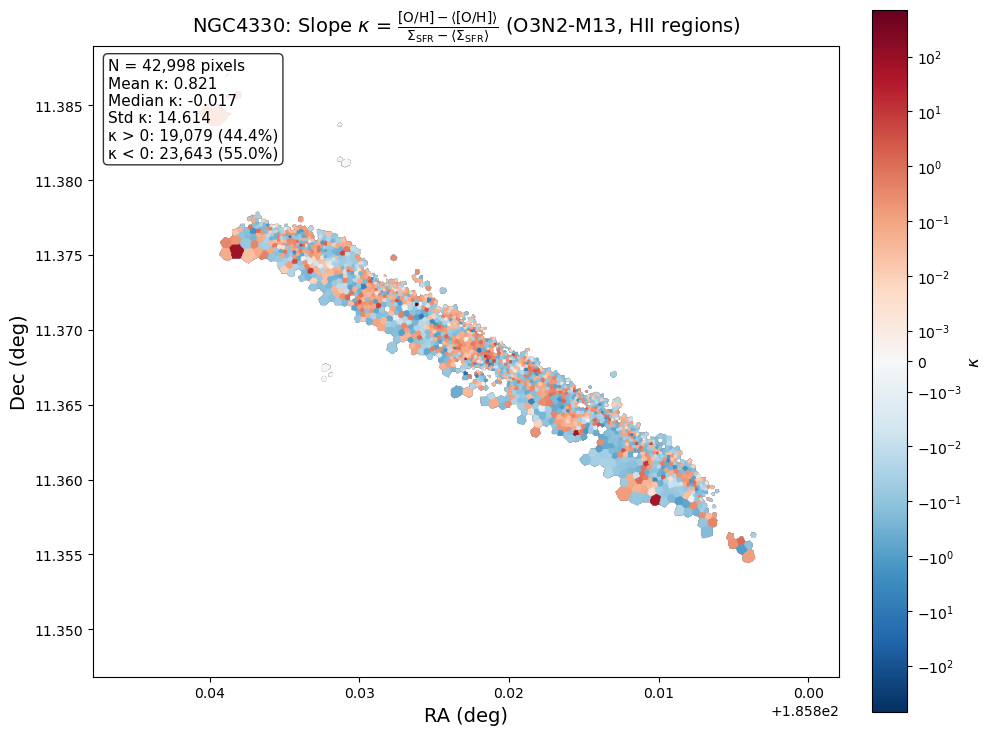


κ map complete!
Overall κ statistics:
  Range: -20.724 to 705.665
  Mean: 0.821, Median: -0.017
  Positive correlation (κ > 0): 44.4%
  Negative correlation (κ < 0): 55.0%


In [11]:
# ------------------------------------------------------------------
# Calculate slope κ (kappa) for [O/H] vs ΣSFR in 12 Σ* bins
# κ = (y - y₀) / (x - x₀), where (x₀, y₀) is the mean (ΣSFR, [O/H]) in each bin
# x = ΣSFR, y = [O/H], z = Σ* (binning variable)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Define 12 Σ* bins (based on pixels with ALL valid data)
    # ------------------------------------------------------------------
    n_bins_sigmaM = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)
    
    # Create a map to store κ values
    kappa_map = np.full_like(sigM, np.nan)
    
    print(f"Calculating slope κ for {gal}...")
    print(f"Total valid pixels: {np.sum(valid_all)}")
    print(f"Σ_* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}\n")
    
    # Flatten arrays for easier processing
    sigM_flat = sigM.flatten()
    sigSFR_flat = sigSFR.flatten()
    oh_flat = oh_o3n2_map.flatten()
    valid_all_flat = valid_all.flatten()
    kappa_flat = np.full_like(sigM_flat, np.nan)
    
    # ------------------------------------------------------------------
    # 3.  Calculate κ for each Σ* bin
    # ------------------------------------------------------------------
    for i in range(n_bins_sigmaM):
        # Select pixels in this Σ* bin
        if i == 0:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat < sigmaM_bin_edges[i+1]) & valid_all_flat
        elif i == n_bins_sigmaM - 1:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat <= sigmaM_bin_edges[i+1]) & valid_all_flat
        else:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat < sigmaM_bin_edges[i+1]) & valid_all_flat
        
        n_pixels = np.sum(in_bin)
        
        if n_pixels > 0:
            # Get x (ΣSFR) and y ([O/H]) for this bin
            x_bin = sigSFR_flat[in_bin]
            y_bin = oh_flat[in_bin]
            
            # Calculate the mean point: (x₀, y₀) = (mean(ΣSFR), mean([O/H]))
            x0 = np.mean(x_bin)
            y0 = np.mean(y_bin)
            
            # Calculate κ = (y - y₀) / (x - x₀) for all points in the bin
            # Handle division by zero: if x == x₀, set κ = 0
            dx = x_bin - x0
            dy = y_bin - y0
            
            kappa_bin = np.zeros_like(dx)
            nonzero_dx = np.abs(dx) > 1e-10  # Avoid division by very small numbers
            kappa_bin[nonzero_dx] = dy[nonzero_dx] / dx[nonzero_dx]
            kappa_bin[~nonzero_dx] = 0  # Set κ = 0 where x ≈ x₀
            
            # Store κ values back into the flattened array
            kappa_flat[in_bin] = kappa_bin
            
            print(f"Bin {i+1}: log(Σ*) = {sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}, N = {n_pixels}")
            print(f"  Mean point: (x₀, y₀) = ({x0:.3f}, {y0:.3f})")
            print(f"  κ range: {np.min(kappa_bin):.3f} to {np.max(kappa_bin):.3f}")
            print(f"  κ mean: {np.mean(kappa_bin):.3f}, median: {np.median(kappa_bin):.3f}\n")
    
    # Reshape kappa back to 2D map
    kappa_map = kappa_flat.reshape(sigM.shape)
    
    # ------------------------------------------------------------------
    # 4.  Visualize the κ map
    # ------------------------------------------------------------------
    from matplotlib.colors import SymLogNorm
    
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Use SymLogNorm for logarithmic colorbar with symmetric handling of negative values
    # linthresh: values between -linthresh and +linthresh are treated linearly
    # linscale: controls the steepness of the linear region
    kappa_max = np.nanmax(np.abs(kappa_map[valid_all]))
    linthresh = 0.001  # Adjust based on your data range
    linscale = 0.5
    
    norm_kappa = SymLogNorm(linthresh=linthresh, linscale=linscale, 
                            vmin=-kappa_max, vmax=kappa_max)
    
    # Display the κ map
    im = ax.imshow(np.ma.masked_invalid(kappa_map), origin='lower', cmap='RdBu_r',
                   extent=extent, norm=norm_kappa)
    ax.set_title(rf'{gal}: Slope $\kappa$ = $\frac{{[\mathrm{{O/H}}] - \langle[\mathrm{{O/H}}]\rangle}}{{\Sigma_{{\mathrm{{SFR}}}} - \langle\Sigma_{{\mathrm{{SFR}}}}\rangle}}$ ({indicator_name}, HII regions)', 
                 fontsize=14)
    ax.set_xlabel('RA (deg)', fontsize=14)
    ax.set_ylabel('Dec (deg)', fontsize=14)
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\kappa$', fontsize=12)
    
    # Add statistics annotation
    kappa_valid = kappa_map[valid_all]
    kappa_mean = np.nanmean(kappa_valid)
    kappa_median = np.nanmedian(kappa_valid)
    kappa_std = np.nanstd(kappa_valid)
    kappa_positive = np.sum(kappa_valid > 0)
    kappa_negative = np.sum(kappa_valid < 0)
    
    textstr = f'N = {np.sum(valid_all):,} pixels\n'
    textstr += f'Mean κ: {kappa_mean:.3f}\n'
    textstr += f'Median κ: {kappa_median:.3f}\n'
    textstr += f'Std κ: {kappa_std:.3f}\n'
    textstr += f'κ > 0: {kappa_positive:,} ({100*kappa_positive/np.sum(valid_all):.1f}%)\n'
    textstr += f'κ < 0: {kappa_negative:,} ({100*kappa_negative/np.sum(valid_all):.1f}%)'
    
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, 
            fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    # plt.savefig(f'{gal}_kappa_map.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{gal}_kappa_map.pdf', bbox_inches='tight')
    plt.show()
    
    print("\nκ map complete!")
    print(f"Overall κ statistics:")
    print(f"  Range: {np.nanmin(kappa_valid):.3f} to {np.nanmax(kappa_valid):.3f}")
    print(f"  Mean: {kappa_mean:.3f}, Median: {kappa_median:.3f}")
    print(f"  Positive correlation (κ > 0): {100*kappa_positive/np.sum(valid_all):.1f}%")
    print(f"  Negative correlation (κ < 0): {100*kappa_negative/np.sum(valid_all):.1f}%")


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_90926/2519560248.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


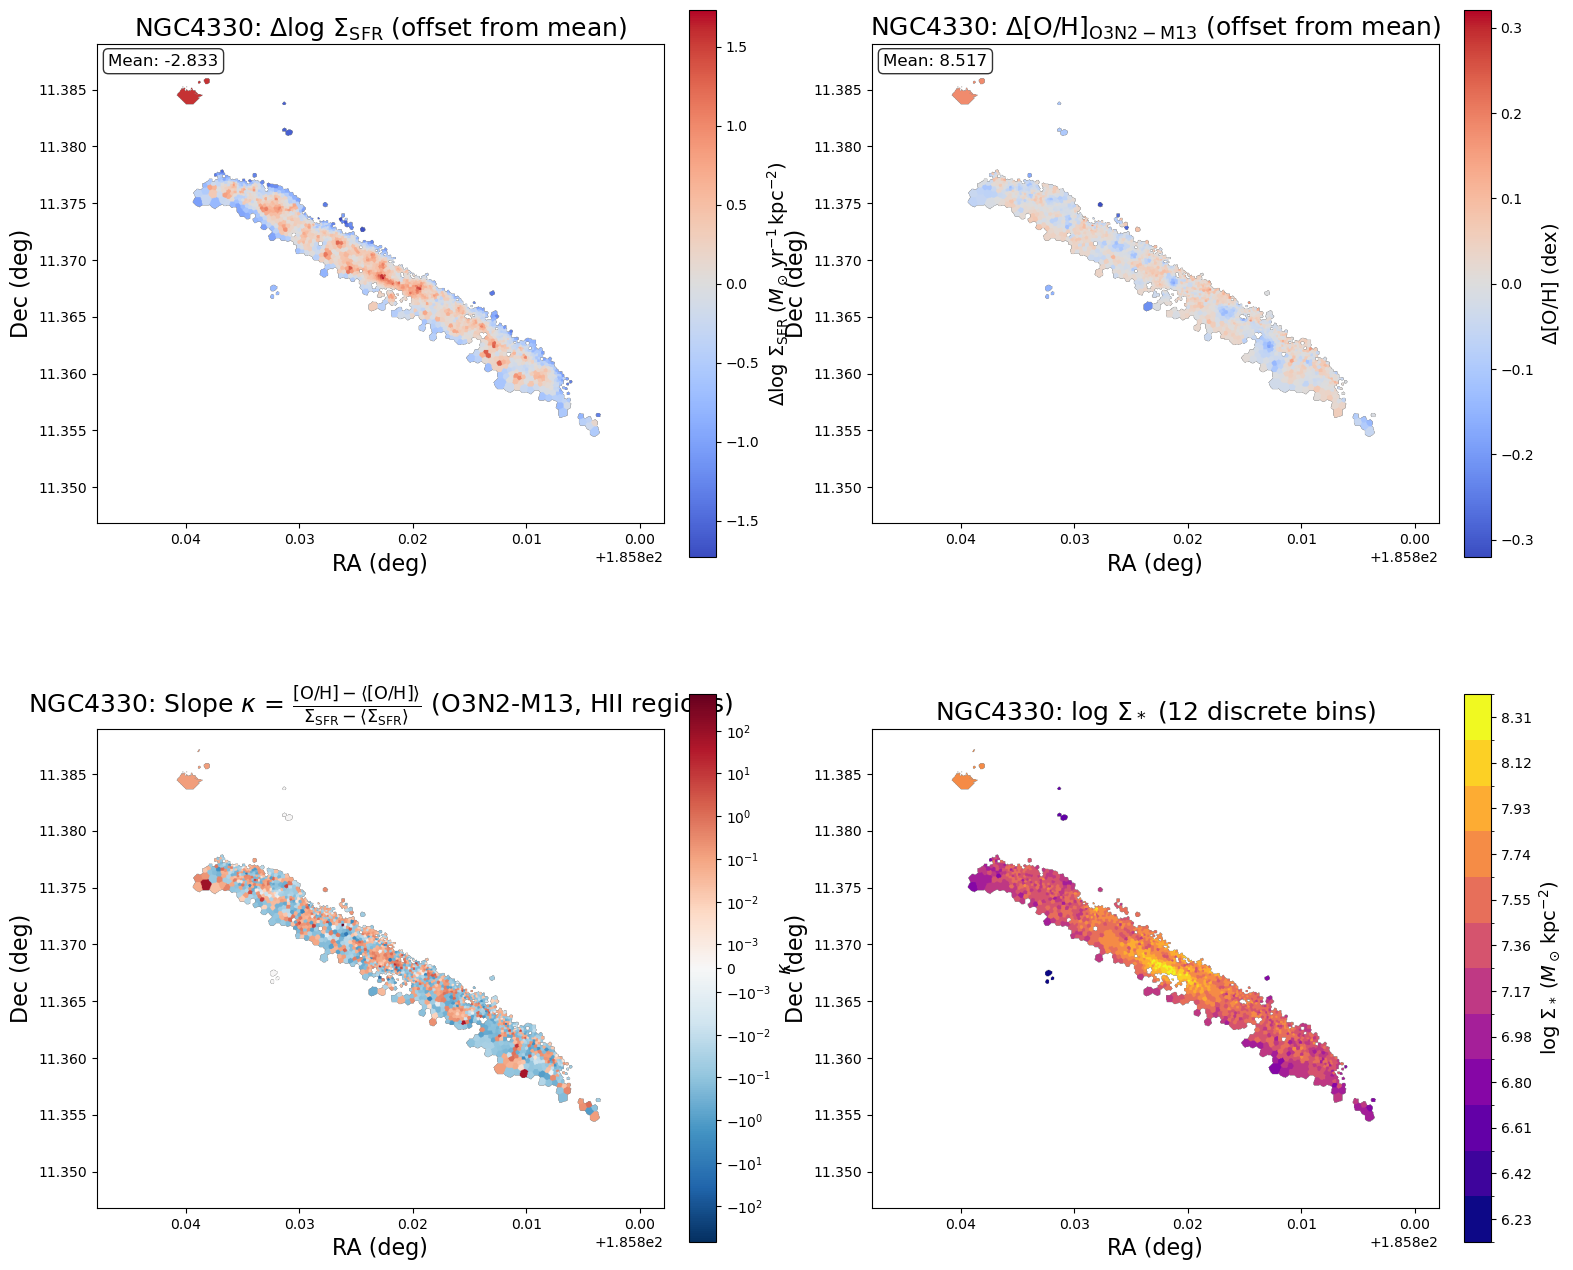


2x2 combined figure complete for NGC4330!
  Σ_SFR offset range: -1.734 to 1.734
  [O/H] offset range: -0.321 to 0.321
  κ range: -20.724 to 705.665
  Σ* bins: 12 bins from 6.135 to 8.400


In [12]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + slope map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate mean values and create offset maps
    # ------------------------------------------------------------------
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
    
    sfr_offset = sigSFR - sfr_mean
    oh_offset = oh_o3n2_map - oh_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_sfr]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_oh]))

    # ------------------------------------------------------------------
    # 3.  Calculate slope κ map (from cell 12)
    # ------------------------------------------------------------------
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    kappa_map = np.full_like(sigM, np.nan)
    
    sigM_flat = sigM.flatten()
    sigSFR_flat = sigSFR.flatten()
    oh_flat = oh_o3n2_map.flatten()
    valid_all_flat = valid_all.flatten()
    kappa_flat = np.full_like(sigM_flat, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat < sigmaM_bin_edges[i+1]) & valid_all_flat
        elif i == n_bins - 1:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat <= sigmaM_bin_edges[i+1]) & valid_all_flat
        else:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat < sigmaM_bin_edges[i+1]) & valid_all_flat
        
        if np.sum(in_bin) > 0:
            x_bin = sigSFR_flat[in_bin]
            y_bin = oh_flat[in_bin]
            
            # Calculate the mean point: (x₀, y₀) = (mean(ΣSFR), mean([O/H]))
            x0 = np.mean(x_bin)
            y0 = np.mean(y_bin)
            
            dx = x_bin - x0
            dy = y_bin - y0
            
            kappa_bin = np.zeros_like(dx)
            nonzero_dx = np.abs(dx) > 1e-10
            kappa_bin[nonzero_dx] = dy[nonzero_dx] / dx[nonzero_dx]
            kappa_bin[~nonzero_dx] = 0
            
            kappa_flat[in_bin] = kappa_bin
    
    kappa_map = kappa_flat.reshape(sigM.shape)

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 6.  Create 2x2 figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    gs = gs_module.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

    # Top-left: Σ_SFR offset map
    ax1 = fig.add_subplot(gs[0, 0])
    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from mean)', fontsize=18)
    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    ax1.text(0.02, 0.98, f'Mean: {sfr_mean:.3f}', transform=ax1.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Top-right: [O/H] offset map
    ax2 = fig.add_subplot(gs[0, 1])
    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                       extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from mean)', fontsize=18)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)
    
    ax2.text(0.02, 0.98, f'Mean: {oh_mean:.3f}', transform=ax2.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-left: Slope κ map with SymLogNorm
    ax3 = fig.add_subplot(gs[1, 0])
    
    kappa_max = np.nanmax(np.abs(kappa_map[valid_all]))
    linthresh = 0.001
    linscale = 0.5
    
    norm_kappa = SymLogNorm(linthresh=linthresh, linscale=linscale, 
                            vmin=-kappa_max, vmax=kappa_max)
    
    im_kappa = ax3.imshow(np.ma.masked_invalid(kappa_map), origin='lower', cmap='RdBu_r',
                          extent=extent, norm=norm_kappa)
    ax3.set_title(rf'{gal}: Slope $\kappa$ = $\frac{{[\mathrm{{O/H}}] - \langle[\mathrm{{O/H}}]\rangle}}{{\Sigma_{{\mathrm{{SFR}}}} - \langle\Sigma_{{\mathrm{{SFR}}}}\rangle}}$ ({indicator_name}, HII regions)', 
                  fontsize=18)
    ax3.set_xlabel('RA (deg)', fontsize=16)
    ax3.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_kappa = fig.colorbar(im_kappa, ax=ax3, fraction=0.046, pad=0.04)
    cbar_kappa.set_label(r'$\kappa$', fontsize=14)

    # Bottom-right: Discrete Σ* binned map
    ax4 = fig.add_subplot(gs[1, 1])
    
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
    ax4.set_xlabel('RA (deg)', fontsize=16)
    ax4.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
    cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Set colorbar ticks at bin centers
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    plt.tight_layout()
    # plt.savefig(f'{gal}_combined_2x2_maps.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{gal}_combined_2x2_maps.pdf', bbox_inches='tight')
    plt.show()

    print(f"\n2x2 combined figure complete for {gal}!")
    print(f"  Σ_SFR offset range: {-sfr_offset_max:.3f} to {sfr_offset_max:.3f}")
    print(f"  [O/H] offset range: {-oh_offset_max:.3f} to {oh_offset_max:.3f}")
    print(f"  κ range: {np.nanmin(kappa_map[valid_all]):.3f} to {np.nanmax(kappa_map[valid_all]):.3f}")
    print(f"  Σ* bins: {n_bins} bins from {sigmaM_min:.3f} to {sigmaM_max:.3f}")

Calculating Pearson correlation for each Σ* bin...
  Bin 1: [6.13, 6.32] - Insufficient unique points (N_unique=1)
  Bin 3: [6.51, 6.70] - Insufficient unique points (N_unique=1)
  Bin 4: [6.70, 6.89] - Insufficient unique points (N_unique=10)
  Bin 5: [6.89, 7.08] - N=3099, N_unique=48, r=-0.175
  Bin 6: [7.08, 7.27] - N=7766, N_unique=202, r=-0.193
  Bin 7: [7.27, 7.46] - N=10108, N_unique=383, r=-0.254
  Bin 8: [7.46, 7.65] - N=10694, N_unique=487, r=-0.230
  Bin 9: [7.65, 7.83] - N=6676, N_unique=340, r=0.595
  Bin 10: [7.83, 8.02] - N=2509, N_unique=181, r=-0.105
  Bin 11: [8.02, 8.21] - N=799, N_unique=77, r=-0.121
  Bin 12: [8.21, 8.40] - N=263, N_unique=30, r=0.083
  Pearson r range: -0.254 to 0.595


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_90926/2942788580.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


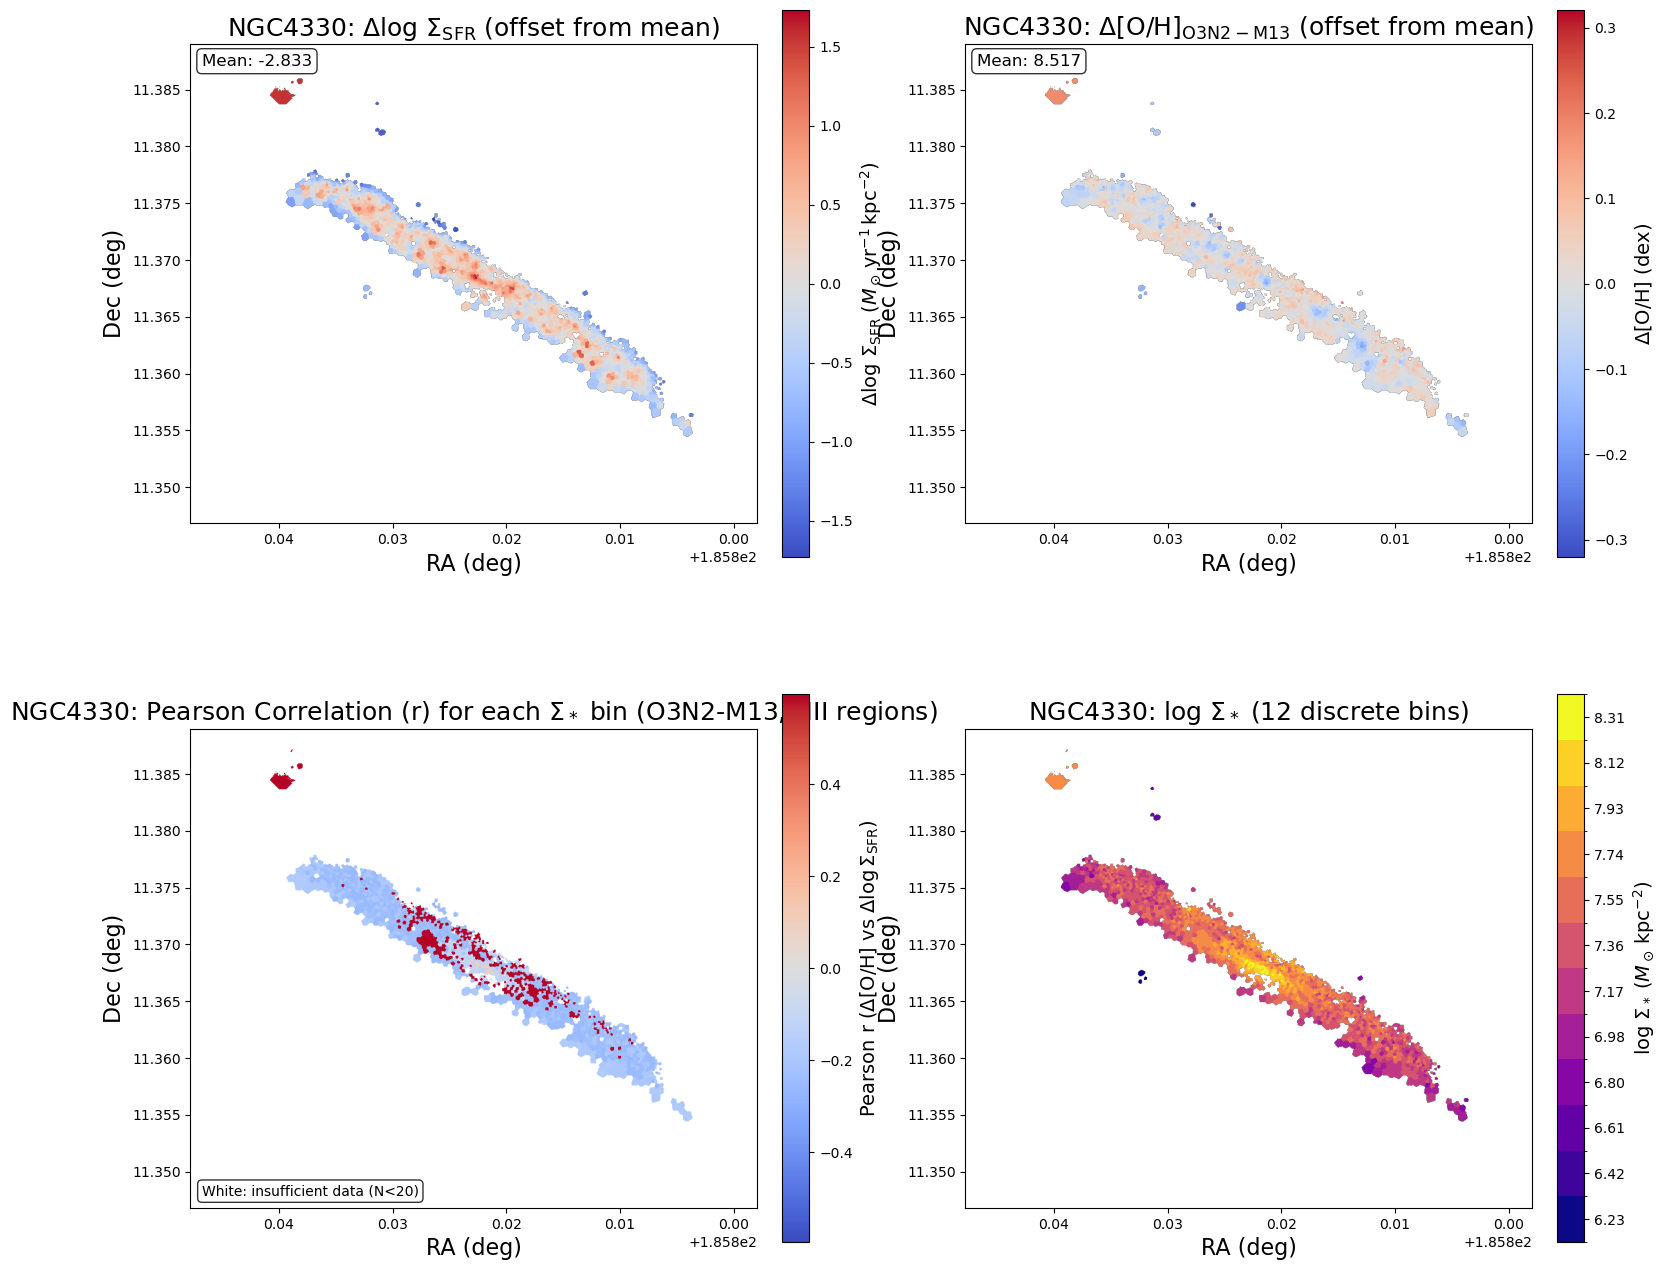


2x2 combined figure complete for NGC4330!
  Σ_SFR offset range: -1.734 to 1.734
  [O/H] offset range: -0.321 to 0.321
  Pearson r range: -0.254 to 0.595
  Σ* bins: 12 bins from 6.135 to 8.400


In [13]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Pearson correlation map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm
from scipy.stats import pearsonr

# Only focus on NGC4330 for this visualisation
galaxies = ['NGC4330']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate mean values and create offset maps
    # ------------------------------------------------------------------
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
    
    sfr_offset = sigSFR - sfr_mean
    oh_offset = oh_o3n2_map - oh_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_sfr]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_oh]))

    # ------------------------------------------------------------------
    # 3.  Calculate Pearson correlation map for each Σ* bin
    # ------------------------------------------------------------------
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    pearson_map = np.full_like(sigM, np.nan)
    
    sigM_flat = sigM.flatten()
    sigSFR_flat = sigSFR.flatten()
    oh_flat = oh_o3n2_map.flatten()
    valid_all_flat = valid_all.flatten()
    pearson_flat = np.full_like(sigM_flat, np.nan)
    
    print(f"Calculating Pearson correlation for each Σ* bin...")
    
    for i in range(n_bins):
        if i == 0:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat < sigmaM_bin_edges[i+1]) & valid_all_flat
        elif i == n_bins - 1:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat <= sigmaM_bin_edges[i+1]) & valid_all_flat
        else:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat < sigmaM_bin_edges[i+1]) & valid_all_flat
        
        if np.sum(in_bin) > 0:
            x_bin = sigSFR_flat[in_bin]
            y_bin = oh_flat[in_bin]
            
            # Calculate Pearson correlation only if >= 20 unique data points
            n_unique = len(np.unique(np.column_stack([x_bin, y_bin]), axis=0))
            
            if n_unique >= 20:
                try:
                    pearson_r, pearson_p = pearsonr(x_bin, y_bin)
                    pearson_flat[in_bin] = pearson_r
                    print(f"  Bin {i+1}: [{sigmaM_bin_edges[i]:.2f}, {sigmaM_bin_edges[i+1]:.2f}] - N={np.sum(in_bin)}, N_unique={n_unique}, r={pearson_r:.3f}")
                except Exception as e:
                    print(f"  Bin {i+1}: [{sigmaM_bin_edges[i]:.2f}, {sigmaM_bin_edges[i+1]:.2f}] - Failed to calculate Pearson: {e}")
            else:
                print(f"  Bin {i+1}: [{sigmaM_bin_edges[i]:.2f}, {sigmaM_bin_edges[i+1]:.2f}] - Insufficient unique points (N_unique={n_unique})")
    
    pearson_map = pearson_flat.reshape(sigM.shape)
    
    # Calculate max absolute Pearson value for colormap scaling
    pearson_valid = pearson_map[np.isfinite(pearson_map)]
    if len(pearson_valid) > 0:
        pearson_max = np.max(np.abs(pearson_valid))
        print(f"  Pearson r range: {np.min(pearson_valid):.3f} to {np.max(pearson_valid):.3f}")
    else:
        pearson_max = 1.0
        print(f"  No valid Pearson correlations calculated!")

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 6.  Create 2x2 figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    gs = gs_module.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

    # Top-left: Σ_SFR offset map
    ax1 = fig.add_subplot(gs[0, 0])
    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from mean)', fontsize=18)
    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    ax1.text(0.02, 0.98, f'Mean: {sfr_mean:.3f}', transform=ax1.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Top-right: [O/H] offset map
    ax2 = fig.add_subplot(gs[0, 1])
    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                       extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from mean)', fontsize=18)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)
    
    ax2.text(0.02, 0.98, f'Mean: {oh_mean:.3f}', transform=ax2.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-left: Pearson correlation map
    ax3 = fig.add_subplot(gs[1, 0])
    
    # Create a custom colormap with white for NaN values
    import matplotlib.colors as mcolors
    cmap_pearson = plt.cm.coolwarm
    cmap_pearson.set_bad(color='white')
    
    im_pearson = ax3.imshow(np.ma.masked_invalid(pearson_map), origin='lower', cmap=cmap_pearson,
                            extent=extent, vmin=-pearson_max, vmax=pearson_max)
    ax3.set_title(rf'{gal}: Pearson Correlation (r) for each $\Sigma_*$ bin ({indicator_name}, HII regions)', 
                  fontsize=18)
    ax3.set_xlabel('RA (deg)', fontsize=16)
    ax3.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_pearson = fig.colorbar(im_pearson, ax=ax3, fraction=0.046, pad=0.04)
    cbar_pearson.set_label(r'Pearson r ($\Delta$[O/H] vs $\Delta\log\Sigma_{\mathrm{SFR}}$)', fontsize=14)
    
    # Add note about white pixels
    ax3.text(0.02, 0.02, 'White: insufficient data (N<20)', transform=ax3.transAxes, 
            fontsize=10, verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-right: Discrete Σ* binned map
    ax4 = fig.add_subplot(gs[1, 1])
    
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
    ax4.set_xlabel('RA (deg)', fontsize=16)
    ax4.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
    cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Set colorbar ticks at bin centers
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    plt.tight_layout()
    # plt.savefig(f'{gal}_combined_2x2_maps_pearson.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{gal}_combined_2x2_maps_pearson.pdf', bbox_inches='tight')
    plt.show()

    print(f"\n2x2 combined figure complete for {gal}!")
    print(f"  Σ_SFR offset range: {-sfr_offset_max:.3f} to {sfr_offset_max:.3f}")
    print(f"  [O/H] offset range: {-oh_offset_max:.3f} to {oh_offset_max:.3f}")
    if len(pearson_valid) > 0:
        print(f"  Pearson r range: {np.min(pearson_valid):.3f} to {np.max(pearson_valid):.3f}")
    print(f"  Σ* bins: {n_bins} bins from {sigmaM_min:.3f} to {sigmaM_max:.3f}")
